# Organizational Trust Quotient (OTQ) — Communication Stream Regression
### Capstone Project | CNM Ingenuity Data Science Bootcamp
**Team:** Vernon T. Cox · Srilatha Alla  
**Roles:** Vernon T. Cox — Co-Researcher & Programmer  ·  Srilatha Alla — Co-Researcher & Programmer  
**Contact:** vcox1@student.cnm.edu  ·  salla@student.cnm.edu

---

## Project Overview

The **Organizational Trust Quotient (OTQ)** is a data-driven framework for passively measuring **communication engagement** as a signal of organizational trust. Rather than asking employees to fill out surveys, the OTQ analyzes communication *metadata* — message frequency, response times, meeting participation, and channel engagement — to produce an objective, numeric engagement signal that is **theorized to reflect** organizational trust. What the pipeline directly measures and predicts is communication engagement and organizational *responsiveness*; trust is the upstream construct those signals are hypothesized to track (see **What OTQ Measures** below and the **Construct Validity** section near the end).

### The Business Problem
Organizations lose significant productivity and revenue due to low trust: delayed decisions, siloed teams, high turnover, and slow response to problems. Traditional trust assessments are infrequent, subjective, and disruptive. The OTQ offers a **minimal-disruption, continuous monitoring alternative** grounded in communication science.

### This Notebook Does the Following
1. Ingests communication exports from Slack, Microsoft Teams, and Outlook Calendar
2. Standardizes them into a single event table
3. Calculates an OTQ Engagement Score (**Event Units / EU**) for each communication event
4. Aggregates features by day and engineers log-transformed predictors
5. Creates a proxy outcome variable (median response time in minutes) from chat sequences
6. Trains a Ridge regression model to predict the outcome from engagement features
7. Performs full EDA and produces inline visualizations
8. Reports model diagnostics (R², MAE, coefficients)

### Data Sources
| Source | Format | Key Fields |
|--------|--------|-----------|
| Slack | JSON export or CSV | timestamp, user, channel, text |
| Microsoft Teams | CSV log extract | timestamp, participants, duration, type |
| Outlook Calendar | CSV export | subject, start, end, organizer, attendees |

## AI Assistance Statement

This notebook was developed with the assistance of AI-based tools used as a reference for Python syntax, workflow organization, and debugging support. AI helped identify issues related to missing values, dataset preparation, model selection, cross-validation protocol, and the proper sequencing of feature engineering, model training, hyperparameter tuning, and held-out evaluation. All code included in this notebook was reviewed, executed, and validated to ensure it performs the intended analysis, and we retain responsibility for understanding the modeling process and interpreting the results.

— Vernon T. Cox and Srilatha Alla, CNM Ingenuity Data Science Bootcamp


## What OTQ Measures — A Note on Construct Scope

The OTQ is computed **entirely from communication metadata**. It is important to be precise about what that does and does not establish:

- **Directly measured / predicted:** communication *engagement* (Event Units) and organizational *responsiveness* (median response time).
- **Theorized, not yet measured:** organizational *trust*. Following Mayer, Davis, and Schoorman (1995), trust is a latent psychological disposition — a *willingness to be vulnerable* — that these behavioral signals are **hypothesized** to reflect, not a quantity captured directly by metadata.

Establishing that the engagement signal genuinely tracks trust is a **construct-validity** question (Cronbach & Meehl, 1955; MacKenzie, Podsakoff, & Podsakoff, 2011), addressed in the **Construct Validity & Planned Convergent-Validity Study** section near the end of this notebook. Throughout, phrases like *“engagement signal”* should be read literally; the word *“trust”* refers to the construct those signals are theorized to reflect.


## Step 1: Imports & Setup

We import all required libraries here. `%matplotlib inline` ensures all plots render directly inside this notebook rather than being saved only to disk.

In [1]:
%matplotlib inline

from __future__ import annotations

import argparse
import json
import math
import re
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Consistent plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Additional reliability libraries (cross-validation, model comparison,
# hyperparameter search, permutation importance, optional text sentiment)
# Pattern inspired by Project 4 (Spotify) and Project 5 (NLP).
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.inspection import permutation_importance

# TextBlob is optional — only used if we add sentiment as a feature later.
try:
    from textblob import TextBlob
    _HAS_TEXTBLOB = True
except Exception:
    _HAS_TEXTBLOB = False
    print("[INFO] TextBlob not installed; sentiment enrichment will be skipped if invoked.")


## Step 2: Helper Functions

These are utility functions used throughout the notebook. They handle type conversion and timestamp parsing safely — avoiding crashes when the data is messy or missing.

In [3]:
def safe_int(x, default=0) -> int:
    try:
        return int(x)
    except Exception:
        return default

def safe_float(x, default=0.0) -> float:
    try:
        return float(x)
    except Exception:
        return default

def parse_datetime(value: Any) -> Optional[pd.Timestamp]:
    """Parse a timestamp value into a UTC-aware pandas Timestamp."""
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return None
    if isinstance(value, pd.Timestamp):
        ts = value
    else:
        s = str(value).strip()
        if re.fullmatch(r"\d{10}(\.\d+)?", s):
            return pd.to_datetime(float(s), unit="s", utc=True)
        ts = pd.to_datetime(s, utc=True, errors="coerce")
    if ts is pd.NaT:
        return None
    if ts.tzinfo is None:
        ts = ts.tz_localize(timezone.utc)
    else:
        ts = ts.tz_convert(timezone.utc)
    return ts

def ensure_dir(p: Path) -> None:
    p.mkdir(parents=True, exist_ok=True)

print("Helper functions defined.")

Helper functions defined.


## Step 3: OTQ Event Unit (EU) Scoring Formula

Each communication event is converted into a single numeric **Event Unit (EU)** score. The formula has three components:

- **Base score** — Different event types carry different engagement weight. A meeting has higher base weight than a quick chat message, because it implies a greater commitment of time and attention.
- **Duration bonus** — Longer interactions (up to 2 hours) add a small increment. This is capped to avoid outliers dominating the score.
- **Participant bonus** — More participants increase the score, but with **diminishing returns** (logarithmic scaling). A 10-person all-hands adds less incremental engagement signal per participant than a focused 2-person conversation.

| Event Type | Base EU |
|-----------|---------|
| Meeting / Teams Meeting | 24.5 |
| Chat / Slack Message | 9.5 |
| Phone / Call | 8.5 |
| Email / Outlook | 6.0 |
| Other | 5.0 |

These weights can be tuned to match an organization's specific OTQ policy.

In [4]:
def otq_event_units(event_type: str, duration_min: float, participant_count: int) -> float:
    """
    Converts a single communication event into a numeric OTQ Event Unit (EU) score.

    Parameters
    ----------
    event_type      : string label (e.g. 'meeting', 'chat', 'email')
    duration_min    : duration in minutes (0 if unknown)
    participant_count: number of people involved (>= 1)

    Returns
    -------
    EU score (float)
    """
    t = (event_type or "").lower()

    if "meeting" in t or "teams_meeting" in t:
        base = 24.5
    elif "call" in t or "phone" in t:
        base = 8.5
    elif "email" in t or "outlook" in t:
        base = 6.0
    elif "chat" in t or "message" in t or "slack" in t:
        base = 9.5
    else:
        base = 5.0

    dur_bonus = min(max(duration_min, 0.0), 120.0) / 60.0        # 0 to 2
    pc = max(participant_count, 1)
    participant_bonus = math.log(pc, 2) * 1.5                     # log scale

    return float(base + dur_bonus + participant_bonus)

print("EU scoring function defined.")

EU scoring function defined.


## Step 4: Data Parsers (Input Ingestion)

These functions read communication export files and normalize them into a **common schema**. Each source (Slack, Outlook, Teams) has its own export format, so the parsers translate each one into the same columns:

`source | event_type | timestamp | actor | channel | text | duration_min | participant_count`

This normalization step is what allows us to combine all data sources for analysis.

In [5]:
def load_csv_any(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, dtype=str, keep_default_na=False)

def load_json_any(path: Path) -> Any:
    text = path.read_text(encoding="utf-8", errors="ignore").strip()
    if not text:
        return []
    if text.lstrip().startswith("{") or text.lstrip().startswith("["):
        return json.loads(text)
    rows = []
    for line in text.splitlines():
        line = line.strip()
        if line:
            rows.append(json.loads(line))
    return rows

def parse_slack_file(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        df = load_csv_any(path)
        ts_col  = next((c for c in df.columns if c.lower() in ["ts","timestamp","time","date"]), None)
        text_col = next((c for c in df.columns if c.lower() in ["text","message","body"]), None)
        user_col = next((c for c in df.columns if c.lower() in ["user","username","from"]), None)
        chan_col = next((c for c in df.columns if c.lower() in ["channel","room","thread"]), None)
        return pd.DataFrame({
            "source": "slack", "event_type": "chat",
            "timestamp": df[ts_col] if ts_col else None,
            "actor": df[user_col] if user_col else None,
            "channel": df[chan_col] if chan_col else None,
            "text": df[text_col] if text_col else None,
            "duration_min": 0.0, "participant_count": 2,
        })
    data = load_json_any(path)
    if isinstance(data, dict): data = [data]
    rows = []
    for obj in data:
        if not isinstance(obj, dict): continue
        rows.append({
            "source": "slack", "event_type": "chat",
            "timestamp": obj.get("ts") or obj.get("timestamp") or obj.get("time"),
            "actor": obj.get("user") or obj.get("username"),
            "channel": obj.get("channel") or obj.get("room"),
            "text": obj.get("text") or obj.get("message"),
            "duration_min": 0.0, "participant_count": 2,
        })
    return pd.DataFrame(rows)

def parse_outlook_calendar_file(path: Path) -> pd.DataFrame:
    df = load_csv_any(path)
    cols = {c.lower(): c for c in df.columns}
    subj  = df[cols["subject"]] if "subject" in cols else ""
    start = df[cols.get("start", cols.get("start time",""))] if ("start" in cols or "start time" in cols) else ""
    end   = df[cols.get("end",   cols.get("end time",""))]   if ("end"   in cols or "end time"   in cols) else ""
    org   = df[cols["organizer"]] if "organizer" in cols else ""
    req   = df[cols["required attendees"]] if "required attendees" in cols else ""
    opt   = df[cols["optional attendees"]] if "optional attendees" in cols else ""
    def count_people(s_req, s_opt):
        def sp(s):
            s = (s or "").strip()
            return [p.strip() for p in re.split(r"[;,]", s) if p.strip()] if s else []
        return max(1, len(set(sp(s_req)+sp(s_opt)))+1)
    part_counts = [count_people(r,o) for r,o in zip(req.tolist(), opt.tolist())]
    return pd.DataFrame({
        "source": "outlook", "event_type": "meeting",
        "timestamp": start, "actor": org, "channel": "calendar", "text": subj,
        "duration_min": np.nan, "participant_count": part_counts,
    })

def parse_teams_file(path: Path) -> pd.DataFrame:
    df = load_csv_any(path)
    cols = {c.lower(): c for c in df.columns}
    ts_col   = next((cols[k] for k in cols if k in ["timestamp","time","date","start","start time","start_time"]), None)
    subj_col = next((cols[k] for k in cols if k in ["subject","title","meeting subject","name"]), None)
    org_col  = next((cols[k] for k in cols if k in ["organizer","from","owner"]), None)
    dur_col  = next((cols[k] for k in cols if k in ["duration","duration_min","minutes"]), None)
    part_col = next((cols[k] for k in cols if k in ["participants","attendees","participant_count"]), None)
    type_col = next((cols[k] for k in cols if k in ["type","interactiontype","event_type"]), None)
    return pd.DataFrame({
        "source": "teams",
        "event_type": df[type_col] if type_col else "teams_meeting",
        "timestamp": df[ts_col] if ts_col else None,
        "actor": df[org_col] if org_col else None,
        "channel": "teams",
        "text": df[subj_col] if subj_col else None,
        "duration_min": df[dur_col] if dur_col else 0.0,
        "participant_count": df[part_col] if part_col else 2,
    })

def discover_inputs(input_dir: Path) -> List[Path]:
    return [p for p in input_dir.rglob("*") if p.is_file() and p.suffix.lower() in {".csv",".json",".jsonl"}]

def parse_any(path: Path) -> Optional[pd.DataFrame]:
    name = path.name.lower()
    try:
        if "slack" in name:     return parse_slack_file(path)
        if "outlook" in name or "calendar" in name:
            if path.suffix.lower() == ".csv": return parse_outlook_calendar_file(path)
            return None
        if "teams" in name:
            if path.suffix.lower() == ".csv": return parse_teams_file(path)
            return None
        if path.suffix.lower() == ".csv":     return parse_teams_file(path)
        return None
    except Exception as e:
        print(f"[WARN] Failed parsing {path}: {e}")
        return None

print("Parsers defined.")

Parsers defined.


## Step 5: Feature Engineering & Outcome Construction

### Data Cleaning Notes
The `build_event_table()` function performs the following cleaning steps:
- **Timestamp normalization**: All timestamps are parsed to UTC-aware format; rows with unparseable timestamps are dropped.
- **Type coercion**: `duration_min` and `participant_count` are safely cast to numeric types; invalid values default to 0.
- **EU scoring**: Applied row-by-row using the formula defined above.
- **Text length**: Character count is computed as a crude proxy for message content volume.

### Outcome Variable (Proxy)
Since live organizational KPI data (e.g., schedule variance, ticket resolution time) is not yet available for this proof-of-concept, we construct a **proxy outcome**: the **median response time in minutes** between consecutive messages within the same communication channel.

A lower response time indicates more fluid, responsive communication. Responsiveness is an **engagement outcome**, not a direct measure of trust; it is hypothesized to be associated with higher trust, a claim that the Construct Validity section addresses explicitly. This proxy will be replaced with real operational KPIs in the full deployment.

### Feature Engineering
Raw daily totals are **log-transformed** (`np.log1p`) before regression. This is standard practice when count-based features are right-skewed — it compresses large values and stabilizes variance, which improves regression performance.

In [6]:
def build_event_table(dfs: List[pd.DataFrame]) -> pd.DataFrame:
    df = pd.concat(dfs, ignore_index=True)
    df["ts"] = df["timestamp"].apply(parse_datetime)
    df = df.dropna(subset=["ts"]).copy()
    df["date"] = df["ts"].dt.floor("D")
    df["duration_min"]    = df["duration_min"].apply(safe_float)
    df["participant_count"] = df["participant_count"].apply(safe_int)
    df["eu"] = [
        otq_event_units(t, d, p)
        for t, d, p in zip(df["event_type"].astype(str), df["duration_min"], df["participant_count"])
    ]
    df["text_len"] = df["text"].fillna("").astype(str).str.len()
    return df

def make_daily_features(events: pd.DataFrame) -> pd.DataFrame:
    g = events.groupby("date", as_index=False).agg(
        total_events    = ("eu", "size"),
        total_eu        = ("eu", "sum"),
        avg_eu          = ("eu", "mean"),
        avg_participants= ("participant_count", "mean"),
        total_text      = ("text_len", "sum"),
        avg_duration    = ("duration_min", "mean"),
    )
    g["log_total_eu"]     = np.log1p(g["total_eu"])
    g["log_total_events"] = np.log1p(g["total_events"])
    g["log_total_text"]   = np.log1p(g["total_text"].clip(lower=0))
    return g

def compute_outcome_proxy(events: pd.DataFrame) -> pd.DataFrame:
    """
    Proxy outcome: median minutes between consecutive messages in the same channel.
    A lower value = more responsive communication (an engagement/responsiveness signal, not a direct trust measure).
    Replace with a real KPI (ticket close rate, schedule variance, etc.) for production.
    """
    e = events.sort_values("ts").copy()
    e["channel_key"] = e["source"].astype(str) + "::" + e["channel"].astype(str)
    e["prev_ts"]     = e.groupby("channel_key")["ts"].shift(1)
    e["delta_min"]   = (e["ts"] - e["prev_ts"]).dt.total_seconds() / 60.0
    e = e[(e["delta_min"].notna()) & (e["delta_min"] > 0) & (e["delta_min"] <= 720)].copy()
    rt = e.groupby("date", as_index=False).agg(
        median_response_min = ("delta_min", "median"),
        p90_response_min    = ("delta_min", lambda s: np.percentile(s, 90)),
        samples             = ("delta_min", "size"),
    )
    return rt

print("Feature engineering & outcome functions defined.")

Feature engineering & outcome functions defined.


## Step 6: Real Data Input — Apostles Communication Database

This notebook loads **three CSV files** containing the **Apostles Communication Database** — a KJV Bible-sourced test dataset structured to match the OTQ pipeline's expected schema.

### How to load the files (choose ONE method below)

| Method | Best for |
|--------|----------|
| **Method A — Colab upload widget** | Running in Google Colab |
| **Method B — Google Drive mount** | Files already in your Google Drive |
| **Method C — Local path** | Running Jupyter locally on your own machine |

The code cell below auto-detects whether you are in Colab and offers the right method. **If you are in Colab, it will show a file picker — select all three CSV files at once.**

| File | Parser | Events |
|------|--------|--------|
| `slack_apostles.csv` | `parse_slack_file()` | 56 chat messages (KJV Epistles & Acts) |
| `teams_apostles.csv` | `parse_teams_file()` | 30 meetings (councils, journeys) |
| `outlook_apostles.csv` | `parse_outlook_calendar_file()` | 20 calendar assemblies |


In [7]:
from pathlib import Path
import os, sys

# ═════════════════════════════════════════════════════════════════════════════
# STEP 6A — Detect environment and load apostles CSV files
# Robust to filename variations: slack_apostles_13.csv, "slack (1).csv", etc.
# Files are matched by KEYWORD (slack / teams / outlook), not exact filename.
# ═════════════════════════════════════════════════════════════════════════════

IN_COLAB = "google.colab" in sys.modules
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# We need one file of each kind. Match on keyword found anywhere in the filename.
REQUIRED_KINDS = ["slack", "teams", "outlook"]
file_store = {}   # will hold {kind: Path} for slack / teams / outlook


def classify(filename: str):
    """Return 'slack'/'teams'/'outlook' based on keywords in the name, else None.
    'calendar' also counts as outlook (Outlook calendar exports)."""
    name = filename.lower()
    if "slack" in name:
        return "slack"
    if "teams" in name:
        return "teams"
    if "outlook" in name or "calendar" in name:
        return "outlook"
    return None


def register(path: Path):
    """Classify a file path and store it under its kind if not already filled."""
    kind = classify(path.name)
    if kind and kind not in file_store:
        file_store[kind] = path
        return kind
    return None


# ─────────────────────────────────────────────────────────────────────────────
# METHOD A — Google Colab file upload widget
# ─────────────────────────────────────────────────────────────────────────────
if IN_COLAB:
    print("Google Colab detected.")
    print("A file picker will appear below.")
    print("Please select your three CSV files (Slack, Teams, Outlook).")
    print("Filenames can include suffixes like '_13' — they are matched by keyword.")
    print()

    from google.colab import files
    uploaded = files.upload()   # shows the file picker

    # Save uploaded bytes to /tmp, then classify by keyword
    for fname, data in uploaded.items():
        dest = Path("/tmp") / fname
        dest.write_bytes(data)
        kind = register(dest)
        tag = f"→ recognized as {kind.upper()}" if kind else "→ ⚠ not recognized (skipped)"
        print(f"  ✓  {fname}  ({len(data)/1024:.1f} KB)  {tag}")

# ─────────────────────────────────────────────────────────────────────────────
# METHOD B — Google Drive mount (uncomment if files are in Drive)
# ─────────────────────────────────────────────────────────────────────────────
# from google.colab import drive
# drive.mount("/content/drive")
# DRIVE_DATA = Path("/content/drive/MyDrive/DataSci_Projects/LongTerm Projects/OrgTrustQuotient/OTQCode/data")
# for p in DRIVE_DATA.glob("*.csv"):
#     register(p)

# ─────────────────────────────────────────────────────────────────────────────
# METHOD C — Local Jupyter (searches common paths automatically)
# ─────────────────────────────────────────────────────────────────────────────
if not IN_COLAB:
    LOCAL_CANDIDATES = [
        Path("./data"),
        Path("."),   # also check the notebook's own folder
        Path("G:/My Drive/DataSci_Projects/LongTerm Projects/OrgTrustQuotient/OTQCode/data"),
        Path("H:/My Drive/DataSci_Projects/LongTerm Projects/OrgTrustQuotient/OTQCode/data"),
        Path.home() / "My Drive/DataSci_Projects/LongTerm Projects/OrgTrustQuotient/OTQCode/data",
    ]
    for candidate in LOCAL_CANDIDATES:
        if candidate.exists():
            # Register any CSV whose name contains a recognized keyword
            for p in sorted(candidate.glob("*.csv")):
                register(p)
        if len(file_store) == 3:
            print(f"✓  All three files found in: {candidate.resolve()}")
            break

    if len(file_store) < 3:
        missing = [k for k in REQUIRED_KINDS if k not in file_store]
        print("❌  Could not auto-locate files for these source(s):")
        for k in missing:
            print(f"   • {k}")
        print()
        print("Options:")
        print("  1. Copy the CSV files into a 'data' subfolder next to this notebook.")
        print("     (Filenames just need to contain 'slack', 'teams', or 'outlook'.)")
        print("  2. Add your folder path to LOCAL_CANDIDATES in the cell above.")
        raise FileNotFoundError(f"Missing source(s): {missing}")

# ─────────────────────────────────────────────────────────────────────────────
# Confirm one file of each kind is ready, then parse
# ─────────────────────────────────────────────────────────────────────────────
missing = [k for k in REQUIRED_KINDS if k not in file_store]
if missing:
    raise FileNotFoundError(
        f"Still missing source(s) after upload: {missing}\n"
        "Make sure you selected one Slack, one Teams, and one Outlook CSV in the picker.\n"
        "(Files are matched by keyword, so 'slack_apostles_13.csv' works fine.)"
    )

print()
print("=" * 60)
print("OTQ DATA INPUT — Apostles Communication Database")
print("=" * 60)
for kind in REQUIRED_KINDS:
    p = file_store[kind]
    rows = sum(1 for _ in open(p)) - 1
    print(f"  ✓  {kind.upper():<8}  {p.name:<28}  {rows:>3} rows")
print()

# ── Parse each file through its OTQ parser ───────────────────────────────────
df_slack   = parse_slack_file(file_store["slack"])
df_teams   = parse_teams_file(file_store["teams"])
df_outlook = parse_outlook_calendar_file(file_store["outlook"])

parsed_frames = [df_slack, df_teams, df_outlook]

print(f"Slack  parser  → {len(df_slack):>3} events loaded")
print(f"Teams  parser  → {len(df_teams):>3} events loaded")
print(f"Outlook parser → {len(df_outlook):>3} events loaded")
print(f"                {'─'*20}")
print(f"Total raw events: {sum(len(d) for d in parsed_frames)}")
print()
print("── Slack sample (first 3 rows) " + "─" * 28)
display(df_slack.head(3))
print()
print("── Teams sample (first 3 rows) " + "─" * 28)
display(df_teams.head(3))
print()
print("── Outlook sample (first 3 rows) " + "─" * 26)
display(df_outlook.head(3))


Google Colab detected.
A file picker will appear below.
Please select your three CSV files (Slack, Teams, Outlook).
Filenames can include suffixes like '_13' — they are matched by keyword.



Saving outlook_apostles_All.csv to outlook_apostles_All.csv
Saving slack_apostles_All.csv to slack_apostles_All.csv
Saving teams_apostles_All.csv to teams_apostles_All.csv
  ✓  outlook_apostles_All.csv  (54.6 KB)  → recognized as OUTLOOK
  ✓  slack_apostles_All.csv  (43.7 KB)  → recognized as SLACK
  ✓  teams_apostles_All.csv  (31.5 KB)  → recognized as TEAMS

OTQ DATA INPUT — Apostles Communication Database
  ✓  SLACK     slack_apostles_All.csv        500 rows
  ✓  TEAMS     teams_apostles_All.csv        400 rows
  ✓  OUTLOOK   outlook_apostles_All.csv      350 rows

Slack  parser  → 500 events loaded
Teams  parser  → 400 events loaded
Outlook parser → 350 events loaded
                ────────────────────
Total raw events: 1250

── Slack sample (first 3 rows) ────────────────────────────


,source,event_type,timestamp,actor,channel,text,duration_min,participant_count
0,slack,chat,2025-06-01 10:30:00,Paul,#tribe_of_dan,Peace I leave with you. John 14:27,0.0,2
1,slack,chat,2025-06-02 09:30:00,James_Alphaeus,#pharisees,Ye are the salt of the earth. Matt 5:13,0.0,2
2,slack,chat,2025-06-02 10:20:00,Simeon_Temple,#church_at_philippi,"Unto us a child is born, unto us a son is give...",0.0,2



── Teams sample (first 3 rows) ────────────────────────────


,source,event_type,timestamp,actor,channel,text,duration_min,participant_count
0,teams,teams_meeting,2025-06-01 10:45:00,Matthew,teams,Judges Assembly — Shechem,90,3
1,teams,teams_meeting,2025-06-02 14:00:00,Uzziah,teams,Apostolic Letter Review — Tarsus,60,15
2,teams,teams_call,2025-06-02 14:15:00,Epaphroditus,teams,Letter Dictation — Beersheba,10,3



── Outlook sample (first 3 rows) ──────────────────────────


,source,event_type,timestamp,actor,channel,text,duration_min,participant_count
0,outlook,meeting,2025-06-01 14:30:00,Apollos,calendar,Council of Apostles — Sinai,NaN,8
1,outlook,meeting,2025-06-03 13:00:00,Apphia,calendar,Tabernacle Service Coordination — Tiberias,NaN,8
2,outlook,meeting,2025-06-04 16:00:00,Jonathan,calendar,Farewell Address — Crete,NaN,16


## Step 7: Build Unified Event Table & Daily Features

Here we merge all three parsed data sources into a single event table, apply the EU scoring formula, and aggregate to daily-level features for modeling.

A key output is the **Apostle Participation Summary** — a per-actor breakdown showing total EU score, event count, and number of unique channels engaged. This is the OTQ equivalent of an individual trust-engagement profile.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Build unified event table from the three apostle data sources
# ─────────────────────────────────────────────────────────────────────────────

events  = build_event_table(parsed_frames)
daily   = make_daily_features(events)
outcome = compute_outcome_proxy(events)

print(f"Unified event table : {events.shape[0]:,} events  x  {events.shape[1]} columns")
print(f"Date range          : {events['date'].min().date()} → {events['date'].max().date()}")
print(f"Daily feature rows  : {daily.shape[0]} days")
print(f"Outcome rows        : {outcome.shape[0]} days with response-time data")
print()

# Apostle participation summary
actor_summary = (
    events.groupby("actor")
    .agg(
        events      = ("eu", "size"),
        total_eu    = ("eu", "sum"),
        avg_eu      = ("eu", "mean"),
        channels    = ("channel", "nunique"),
    )
    .sort_values("total_eu", ascending=False)
    .round(2)
)
print("── Apostle Participation Summary (by Total EU Score) " + "─" * 8)
display(actor_summary)
print()
print("── Unified Event Table — first 8 rows " + "─" * 22)
display(events[["source","event_type","date","actor","channel","duration_min","participant_count","eu"]].head(8))
print()
print("── Daily Feature Table — first 5 rows " + "─" * 22)
display(daily.head())


Unified event table : 1,250 events  x  12 columns
Date range          : 2025-06-01 → 2025-11-30
Daily feature rows  : 183 days
Outcome rows        : 154 days with response-time data

── Apostle Participation Summary (by Total EU Score) ────────


,events,total_eu,avg_eu,channels
actor,,,,
Paul,77,797.28,15.63,28
Timothy,32,416.35,16.65,15
Jeremiah,26,380.14,19.01,12
Ezra,24,379.99,18.09,10
Mark,29,369.95,15.41,14
...,...,...,...,...
Damaris,3,0.00,NaN,1
Enoch,2,0.00,NaN,1
Reuben,2,0.00,NaN,1



── Unified Event Table — first 8 rows ──────────────────────


,source,event_type,date,actor,channel,duration_min,participant_count,eu
0,slack,chat,2025-06-01 00:00:00+00:00,Paul,#tribe_of_dan,0.0,2,11.0
1,slack,chat,2025-06-02 00:00:00+00:00,James_Alphaeus,#pharisees,0.0,2,11.0
2,slack,chat,2025-06-02 00:00:00+00:00,Simeon_Temple,#church_at_philippi,0.0,2,11.0
3,slack,chat,2025-06-03 00:00:00+00:00,Paul,#nazarites,0.0,2,11.0
4,slack,chat,2025-06-03 00:00:00+00:00,Elisha,#tribe_of_judah,0.0,2,11.0
5,slack,chat,2025-06-04 00:00:00+00:00,Jonah,#tribe_of_dan,0.0,2,11.0
6,slack,chat,2025-06-04 00:00:00+00:00,Elijah,#the_twelve,0.0,2,11.0
7,slack,chat,2025-06-04 00:00:00+00:00,Mordecai,#tribe_of_manasseh,0.0,2,11.0



── Daily Feature Table — first 5 rows ──────────────────────


,date,total_events,total_eu,avg_eu,avg_participants,total_text,avg_duration,log_total_eu,log_total_events,log_total_text
0,2025-06-01 00:00:00+00:00,3,39.377444,19.688722,4.333333,86,45.000000,3.698271,1.386294,4.465908
1,2025-06-02 00:00:00+00:00,5,92.904446,18.580889,5.200000,187,26.000000,4.542278,1.791759,5.236442
2,2025-06-03 00:00:00+00:00,7,88.777662,14.796277,5.000000,266,18.666667,4.497336,2.079442,5.587249
3,2025-06-04 00:00:00+00:00,6,56.044110,11.208822,4.500000,199,2.000000,4.043825,1.945910,5.298317
4,2025-06-05 00:00:00+00:00,9,84.678103,21.169526,8.666667,315,41.250000,4.450597,2.302585,5.755742


## Step 7b: Data Health Check (Reliability)

Before modeling, we run a structured health check on the unified event table and the daily feature/outcome tables. This mirrors the **schema introspection** pattern from Project 3 (Chinook SQLite exploration) and the **`info()` + missing-value audit** pattern from Project 5 (NLP). Catching schema or completeness problems *now* prevents silent bugs later in the modeling stage.

Three things to verify:

1. **Schema**: column names, dtypes, and which columns are populated.
2. **Completeness**: missing-value counts and rows lost after each transformation.
3. **Range sanity**: do EU scores, durations, and participant counts sit in plausible ranges?


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Reliability check #1 — schema audit of every working table.
# Pattern: Project 3 used `PRAGMA table_info` to list every column;
# we use pandas .dtypes which is the in-memory equivalent.
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("SCHEMA AUDIT — UNIFIED EVENT TABLE")
print("=" * 60)
events.info()

print()
print("=" * 60)
print("SCHEMA AUDIT — DAILY FEATURE TABLE")
print("=" * 60)
daily.info()

print()
print("=" * 60)
print("SCHEMA AUDIT — OUTCOME TABLE")
print("=" * 60)
outcome.info()

# ─────────────────────────────────────────────────────────────────────────────
# Reliability check #2 — completeness audit.
# Missing values are absence-as-signal in OTQ, but at the modeling stage we
# need to know exactly how many rows we lose at each join. Surfacing this
# explicitly prevents the silent "modeling on 12 days instead of 90" bug.
# ─────────────────────────────────────────────────────────────────────────────
print()
print("=" * 60)
print("COMPLETENESS AUDIT — ROW COUNTS THROUGH THE PIPELINE")
print("=" * 60)
print(f"  Raw events                                : {len(events):>6,}")
print(f"  Daily feature rows                        : {len(daily):>6,}")
print(f"  Daily outcome rows                        : {len(outcome):>6,}")
print(f"  Days with BOTH features and outcome (join): {len(daily.merge(outcome, on='date', how='inner')):>6,}")
print(f"  Days with features but NO outcome         : {len(daily) - len(daily.merge(outcome, on='date', how='inner')):>6,}")

# ─────────────────────────────────────────────────────────────────────────────
# Reliability check #3 — range sanity on numeric columns.
# Catches things like negative durations or participant counts of 0.
# ─────────────────────────────────────────────────────────────────────────────
print()
print("=" * 60)
print("RANGE SANITY — NUMERIC COLUMNS")
print("=" * 60)
sanity_rows = []
for col, lo, hi in [
    ("duration_min",      0,    24 * 60),
    ("participant_count", 1,    50),
    ("eu",                0,    100),
    ("text_len",          0,    10_000),
]:
    if col in events.columns:
        s = events[col]
        sanity_rows.append({
            "column":      col,
            "min":         round(float(s.min()), 2) if len(s) else None,
            "max":         round(float(s.max()), 2) if len(s) else None,
            "expected_lo": lo,
            "expected_hi": hi,
            "out_of_range": int(((s < lo) | (s > hi)).sum()),
        })
sanity_df = pd.DataFrame(sanity_rows)
display(sanity_df)

print()
print("Interpretation: out_of_range > 0 in any row above warns that the parser")
print("or upstream data has anomalies. EU is uncapped by design, so high values")
print("there are informative rather than alarming.")


SCHEMA AUDIT — UNIFIED EVENT TABLE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   source             1250 non-null   object             
 1   event_type         1250 non-null   object             
 2   timestamp          1250 non-null   object             
 3   actor              1250 non-null   object             
 4   channel            1250 non-null   object             
 5   text               1250 non-null   object             
 6   duration_min       900 non-null    float64            
 7   participant_count  1250 non-null   int64              
 8   ts                 1250 non-null   datetime64[ns, UTC]
 9   date               1250 non-null   datetime64[ns, UTC]
 10  eu                 900 non-null    float64            
 11  text_len           1250 non-null   int64              
dtypes: datetime64

,column,min,max,expected_lo,expected_hi,out_of_range
0,duration_min,0.00,180.00,0,1440,0
1,participant_count,2.00,20.00,1,50,0
2,eu,10.08,32.98,0,100,0
3,text_len,17.00,70.00,0,10000,0



Interpretation: out_of_range > 0 in any row above warns that the parser
or upstream data has anomalies. EU is uncapped by design, so high values
there are informative rather than alarming.


## Step 8: Data Overview

This section satisfies the Week 13 capstone requirement for a **data overview**: shape, column types, missing values, and basic descriptive statistics.

In [10]:
print("=" * 55)
print("EVENT TABLE — SHAPE")
print("=" * 55)
print(f"  Rows    : {events.shape[0]:,}")
print(f"  Columns : {events.shape[1]}")

print()
print("=" * 55)
print("COLUMN TYPES")
print("=" * 55)
print(events.dtypes)

print()
print("=" * 55)
print("MISSING VALUES (NaN count per column)")
print("=" * 55)
print(events.isna().sum())

print()
print("=" * 55)
print("DESCRIPTIVE STATISTICS (numeric columns)")
print("=" * 55)
display(events[["duration_min","participant_count","eu","text_len"]].describe().round(2))

EVENT TABLE — SHAPE
  Rows    : 1,250
  Columns : 12

COLUMN TYPES
source                            object
event_type                        object
timestamp                         object
actor                             object
channel                           object
text                              object
duration_min                     float64
participant_count                  int64
ts                   datetime64[ns, UTC]
date                 datetime64[ns, UTC]
eu                               float64
text_len                           int64
dtype: object

MISSING VALUES (NaN count per column)
source                 0
event_type             0
timestamp              0
actor                  0
channel                0
text                   0
duration_min         350
participant_count      0
ts                     0
date                   0
eu                   350
text_len               0
dtype: int64

DESCRIPTIVE STATISTICS (numeric columns)


,duration_min,participant_count,eu,text_len
count,900.00,1250.00,900.00,1250.00
mean,26.96,6.23,16.53,35.38
std,46.65,5.18,8.80,9.21
min,0.00,2.00,10.08,17.00
25%,0.00,2.00,11.00,28.00
50%,0.00,3.00,11.00,34.00
75%,45.00,10.00,28.56,40.00
max,180.00,20.00,32.98,70.00


## Step 9: Exploratory Data Analysis (EDA)

### Why this EDA?

Before modeling, we need to understand the shape and distribution of our data. The key questions are:

1. **Are the features normally distributed, or skewed?** — Skewed features need log-transformation before linear regression.
2. **Do engagement features correlate with each other?** — High multicollinearity can inflate regression coefficients; Ridge regression helps mitigate this.
3. **Is there a visible relationship between engagement and response time?** — If engagement (EU) and response time move together, regression is well-motivated.
4. **How does communication volume vary over time?** — Temporal patterns (weekly cycles, spikes) inform whether we need time-based features.

The EDA findings directly shaped the modeling decisions in Step 10.

/tmp/ipykernel_1981/1890346915.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=events, x="event_type", y="eu", order=event_order, ax=axes[1,0], palette="muted")


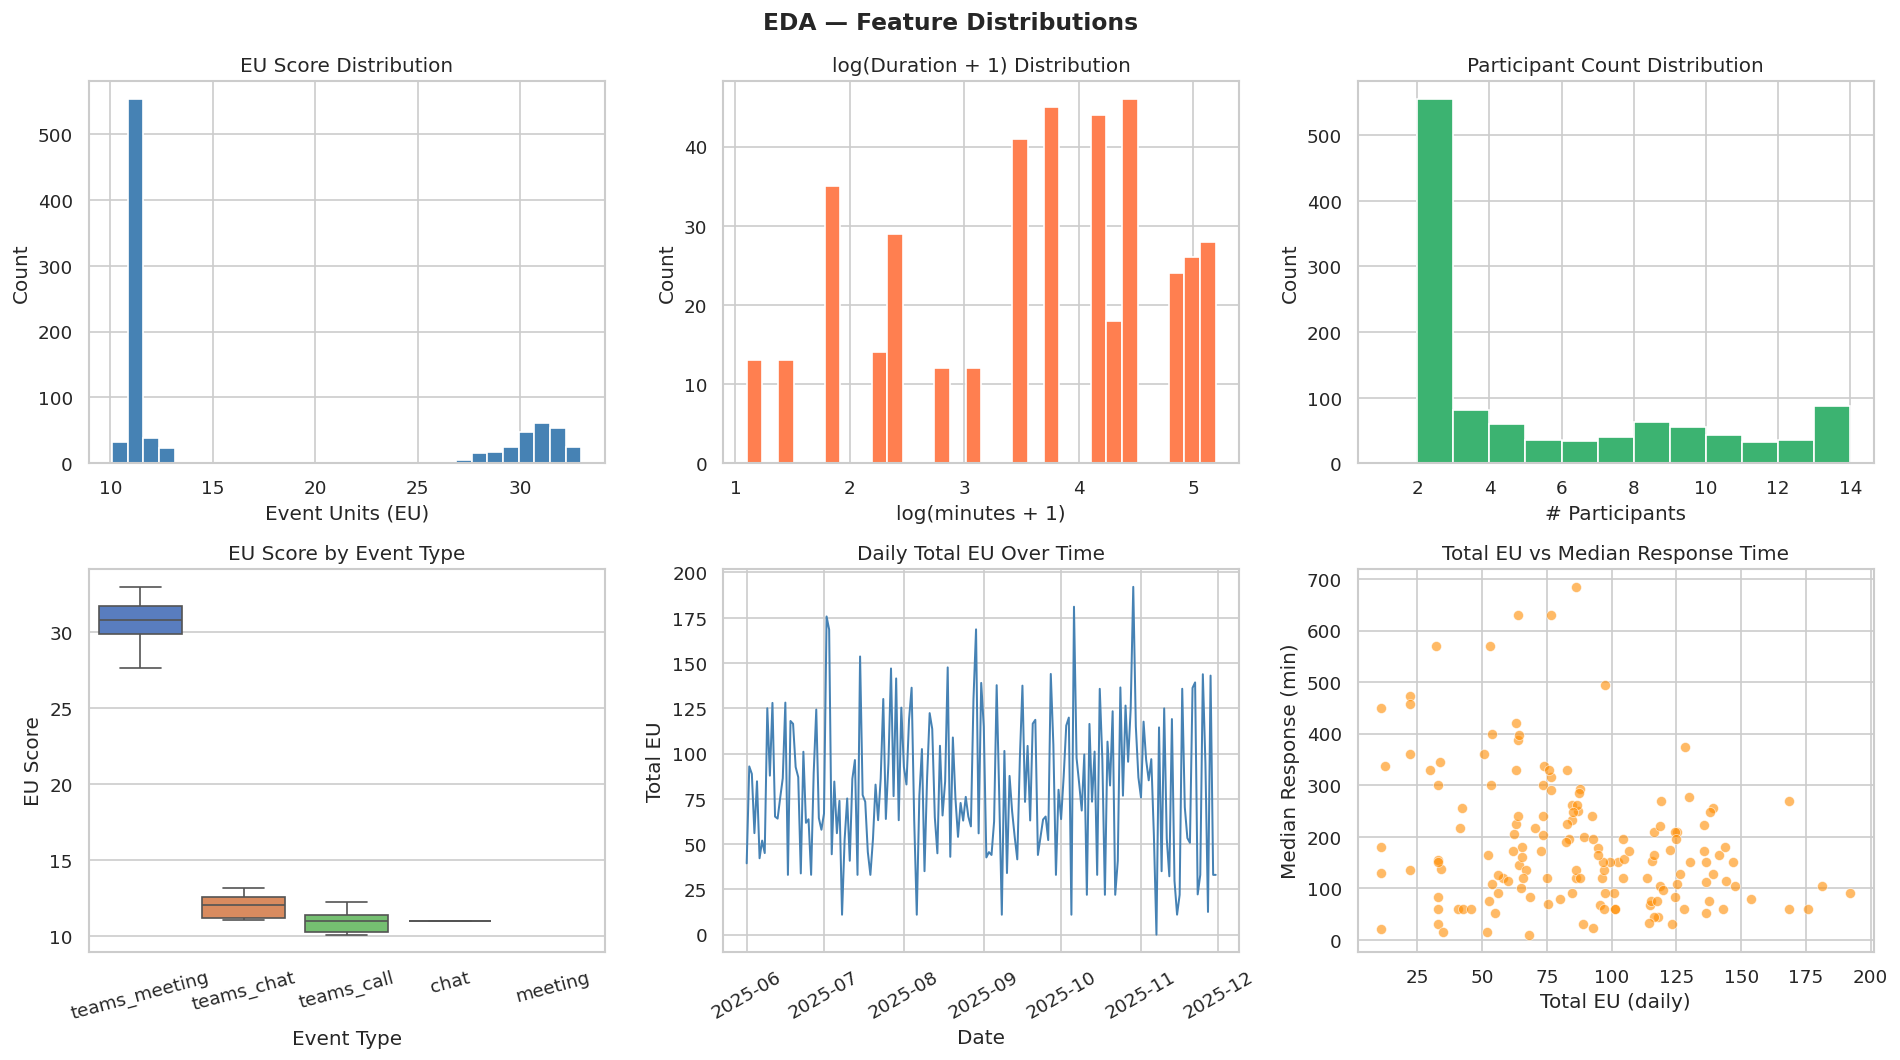

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("EDA — Feature Distributions", fontsize=14, fontweight="bold")

# EU score distribution
axes[0,0].hist(events["eu"], bins=30, color="steelblue", edgecolor="white")
axes[0,0].set_title("EU Score Distribution")
axes[0,0].set_xlabel("Event Units (EU)")
axes[0,0].set_ylabel("Count")

# Duration distribution (log scale)
dur_nonzero = events.loc[events["duration_min"] > 0, "duration_min"]
axes[0,1].hist(np.log1p(dur_nonzero), bins=30, color="coral", edgecolor="white")
axes[0,1].set_title("log(Duration + 1) Distribution")
axes[0,1].set_xlabel("log(minutes + 1)")
axes[0,1].set_ylabel("Count")

# Participant count
axes[0,2].hist(events["participant_count"], bins=range(1,15), color="mediumseagreen", edgecolor="white")
axes[0,2].set_title("Participant Count Distribution")
axes[0,2].set_xlabel("# Participants")
axes[0,2].set_ylabel("Count")

# EU by event type (boxplot)
event_order = events.groupby("event_type")["eu"].median().sort_values(ascending=False).index
sns.boxplot(data=events, x="event_type", y="eu", order=event_order, ax=axes[1,0], palette="muted")
axes[1,0].set_title("EU Score by Event Type")
axes[1,0].set_xlabel("Event Type")
axes[1,0].set_ylabel("EU Score")
axes[1,0].tick_params(axis="x", rotation=15)

# Daily total EU over time
axes[1,1].plot(daily["date"], daily["total_eu"], color="steelblue", linewidth=1.2)
axes[1,1].set_title("Daily Total EU Over Time")
axes[1,1].set_xlabel("Date")
axes[1,1].set_ylabel("Total EU")
axes[1,1].tick_params(axis="x", rotation=30)

# EU vs response time scatter
merged_eda = daily.merge(outcome, on="date", how="inner")
axes[1,2].scatter(merged_eda["total_eu"], merged_eda["median_response_min"],
                  alpha=0.6, color="darkorange", edgecolors="white", linewidths=0.5)
axes[1,2].set_title("Total EU vs Median Response Time")
axes[1,2].set_xlabel("Total EU (daily)")
axes[1,2].set_ylabel("Median Response (min)")

plt.tight_layout()
plt.show()

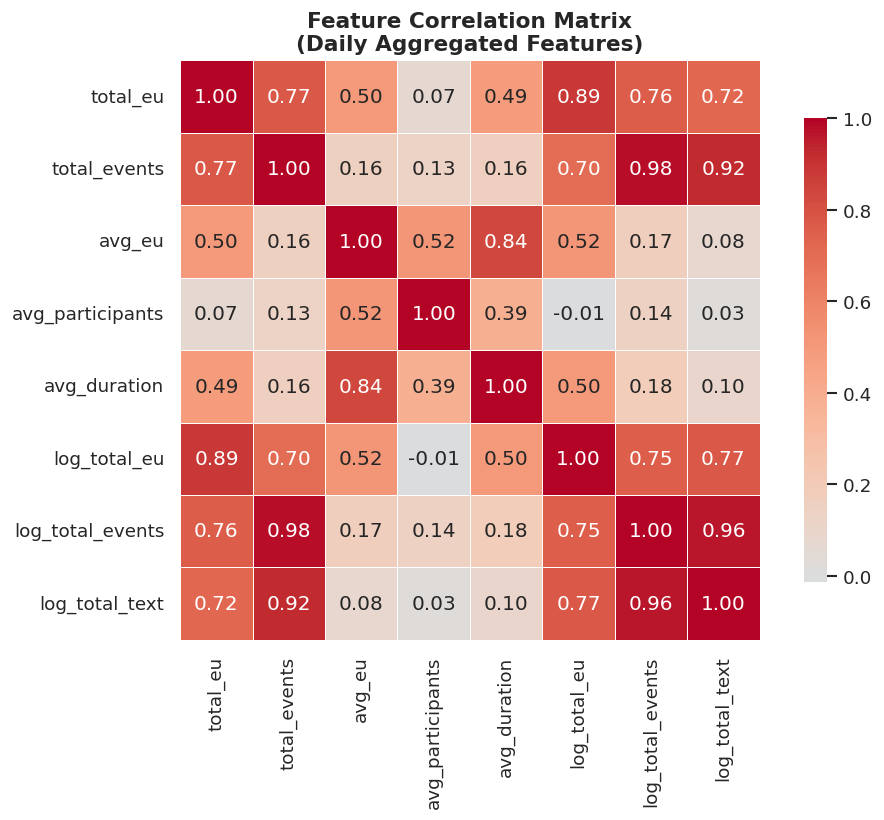


Key finding: total_eu and total_events are highly correlated (expected —
more events = more EU). Log transforms reduce this collinearity.
Ridge regression is appropriate given these correlated predictors.


In [12]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(9, 7))

corr_cols = ["total_eu","total_events","avg_eu","avg_participants","avg_duration",
             "log_total_eu","log_total_events","log_total_text"]
corr_df = daily[corr_cols].copy()
corr_matrix = corr_df.corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax, square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix\n(Daily Aggregated Features)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print()
print("Key finding: total_eu and total_events are highly correlated (expected —")
print("more events = more EU). Log transforms reduce this collinearity.")
print("Ridge regression is appropriate given these correlated predictors.")

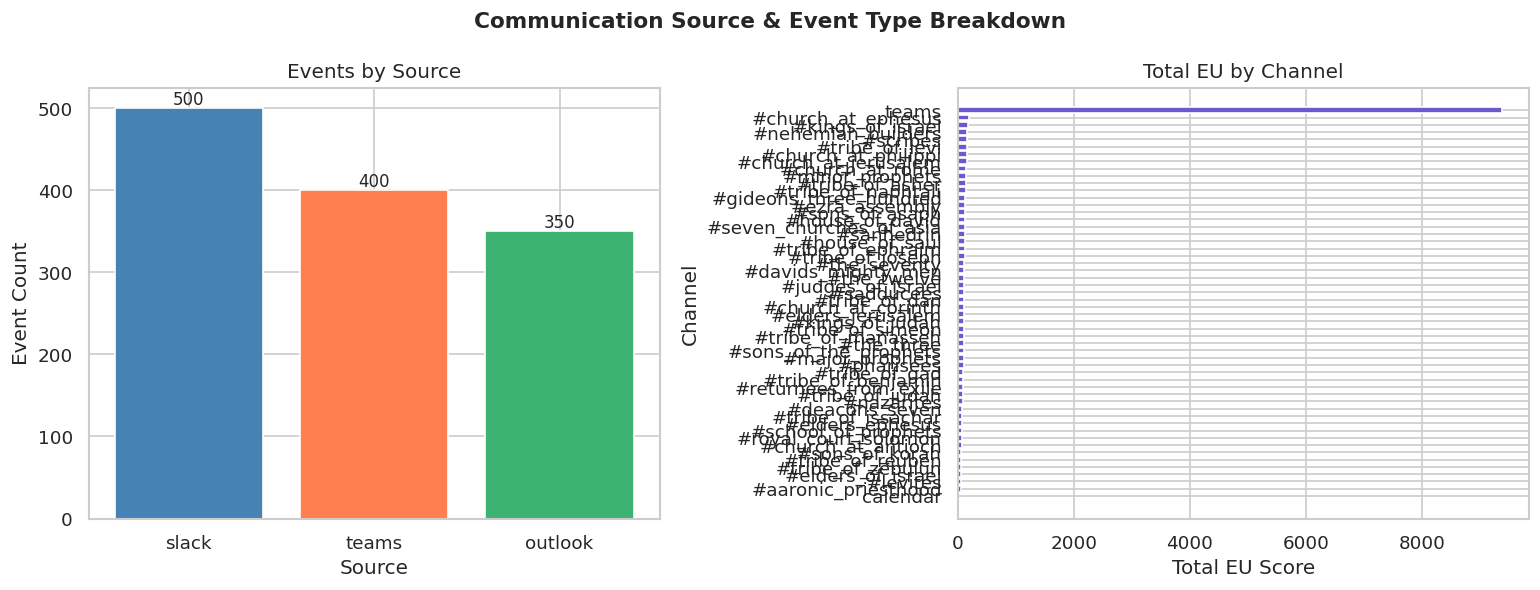

In [13]:
# Event type breakdown by source
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Communication Source & Event Type Breakdown", fontsize=13, fontweight="bold")

source_counts = events["source"].value_counts()
axes[0].bar(source_counts.index, source_counts.values, color=["steelblue","coral","mediumseagreen"])
axes[0].set_title("Events by Source")
axes[0].set_xlabel("Source")
axes[0].set_ylabel("Event Count")
for i, v in enumerate(source_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=10)

channel_eu = events.groupby("channel")["eu"].sum().sort_values(ascending=True)
axes[1].barh(channel_eu.index, channel_eu.values, color="slateblue")
axes[1].set_title("Total EU by Channel")
axes[1].set_xlabel("Total EU Score")
axes[1].set_ylabel("Channel")

plt.tight_layout()
plt.show()

## Step 10: Modeling — Ridge Regression

### Model Choice: Why Ridge Regression?

Based on the EDA in Step 9, we observed **high multicollinearity** among engagement features (e.g., `total_eu` and `total_events` correlate at r > 0.95). In ordinary least squares (OLS) regression, multicollinearity inflates coefficient variance and makes estimates unstable — small changes in the data lead to large swings in coefficients.

**Ridge regression** adds an L2 regularization penalty (controlled by `alpha`) that shrinks correlated coefficients toward zero, stabilizing the model without eliminating features entirely. This is preferred over Lasso (L1) here because all five features are theoretically meaningful and we want to retain them.

### Features Used
| Feature | Description |
|---------|-------------|
| `log_total_eu` | Log of daily total engagement score |
| `log_total_events` | Log of daily event count |
| `avg_participants` | Average participants per event |
| `avg_duration` | Average event duration (minutes) |
| `log_total_text` | Log of total message character volume |

### Target Variable
`median_response_min` — median minutes between consecutive messages in the same channel. This is an **operational responsiveness outcome**; organizational trust is the theorized upstream construct and is **not** measured directly here (see Construct Validity).

In [14]:
# Merge daily features with outcome
model_df = daily.merge(outcome, on="date", how="inner").copy()
print(f"Modeling dataset: {len(model_df)} days with both features and outcome")

feature_cols = ["log_total_eu","log_total_events","avg_participants","avg_duration","log_total_text"]
target_col   = "median_response_min"

X = model_df[feature_cols].fillna(0.0).to_numpy()
y = model_df[target_col].fillna(model_df[target_col].median()).to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Fit Ridge regression
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

pred_train = model.predict(X_train)
pred_test  = model.predict(X_test)

print()
print("=" * 40)
print("REGRESSION RESULTS")
print("=" * 40)
print(f"  Training R²  : {r2_score(y_train, pred_train):.3f}")
print(f"  Test R²      : {r2_score(y_test, pred_test):.3f}")
print(f"  Test MAE     : {mean_absolute_error(y_test, pred_test):.2f} minutes")

coefs = pd.DataFrame({"Feature": feature_cols, "Coefficient": model.coef_})
coefs = coefs.reindex(coefs["Coefficient"].abs().sort_values(ascending=False).index)
print()
print("COEFFICIENTS (sorted by absolute magnitude):")
print(coefs.to_string(index=False))
print()
print("Interpretation: Negative coefficients mean higher engagement predicts")
print("shorter response times (more responsive communication).")

Modeling dataset: 154 days with both features and outcome

REGRESSION RESULTS
  Training R²  : 0.061
  Test R²      : 0.108
  Test MAE     : 98.37 minutes

COEFFICIENTS (sorted by absolute magnitude):
         Feature  Coefficient
log_total_events   -85.369265
    log_total_eu    -7.076521
  log_total_text     3.080574
avg_participants    -1.261021
    avg_duration    -0.160594

Interpretation: Negative coefficients mean higher engagement predicts
shorter response times (more responsive communication).


### Step 10a: Cross-Validated Ridge Baseline (Reliability)

A single 75/25 train/test split (above) gives one estimate of generalization. **Project 4 (Spotify)** taught us a more robust approach: **K-fold cross-validation**, which runs the model on 5 different train/validation partitions and reports the mean plus standard deviation. The std is the signal — if it's large relative to the mean, the model is fragile and the headline R² number is partly luck of the split.


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Reusable CV evaluator — borrowed from Project 4 (Spotify) and adapted to
# regression-of-response-time. We report RMSE (in minutes) because it is in
# the same units as the target and easy to talk about with stakeholders.
# 5-fold is the standard default; shuffle=True with a fixed random_state makes
# the split reproducible without baking calendar order into the folds.
# ─────────────────────────────────────────────────────────────────────────────
def cv_rmse(estimator, X, y, n_splits=5, random_state=42):
    """Return per-fold RMSE for `estimator` under K-fold CV."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    neg_mse = cross_val_score(estimator, X, y, scoring="neg_mean_squared_error", cv=kf)
    return np.sqrt(-neg_mse)


def cv_r2(estimator, X, y, n_splits=5, random_state=42):
    """Return per-fold R^2 for `estimator` under K-fold CV."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    return cross_val_score(estimator, X, y, scoring="r2", cv=kf)


# Run the cross-validated baseline on the same Ridge(alpha=1.0) used above.
# X, y are already defined in Step 10 (cell above); we reuse them directly.
baseline = Ridge(alpha=1.0)
fold_rmse = cv_rmse(baseline, X, y)
fold_r2   = cv_r2(baseline,   X, y)

print("=" * 50)
print("5-FOLD CROSS-VALIDATED RIDGE BASELINE")
print("=" * 50)
print(f"  Per-fold RMSE (min): {np.round(fold_rmse, 2).tolist()}")
print(f"  Mean RMSE          : {fold_rmse.mean():.2f} minutes")
print(f"  Std  RMSE          : {fold_rmse.std():.2f} minutes")
print(f"  Per-fold R^2       : {np.round(fold_r2, 3).tolist()}")
print(f"  Mean R^2           : {fold_r2.mean():.3f}")
print(f"  Std  R^2           : {fold_r2.std():.3f}")
print()
print("Interpretation: a small Std RMSE relative to the Mean indicates the model")
print("generalizes consistently across different slices of the data. A large Std")
print("would warn that the single-split R^2 reported above is partly luck.")


5-FOLD CROSS-VALIDATED RIDGE BASELINE
  Per-fold RMSE (min): [135.82, 156.72, 108.28, 128.13, 130.91]
  Mean RMSE          : 131.97 minutes
  Std  RMSE          : 15.52 minutes
  Per-fold R^2       : [0.084, -0.207, 0.06, -0.002, -0.127]
  Mean R^2           : -0.038
  Std  R^2           : 0.112

Interpretation: a small Std RMSE relative to the Mean indicates the model
generalizes consistently across different slices of the data. A large Std
would warn that the single-split R^2 reported above is partly luck.


### Step 10b: Alpha Sweep — Choosing Ridge Regularization Empirically

`alpha=1.0` was a reasonable default, but **Project 4 (Spotify)** swept `max_depth` across a range and picked the value that minimized cross-validated RMSE. For Ridge, the analogous knob is **`alpha`** (the regularization strength). We sweep across several orders of magnitude and visualize the curve.


Ridge alpha sweep:
    alpha  Mean CV RMSE  Std  CV RMSE
   0.0010       132.622        15.216
   0.0032       132.614        15.220
   0.0100       132.588        15.232
   0.0316       132.517        15.268
   0.1000       132.362        15.353
   0.3162       132.154        15.478
   1.0000       131.972        15.520
   3.1623       131.757        15.338
  10.0000       131.549        14.901
  31.6228       131.521        14.309
 100.0000       131.845        13.845
 316.2278       132.124        13.677
1000.0000       132.108        13.694

Best alpha (lowest CV RMSE): 31.6228
  -> Mean CV RMSE at best : 131.521 minutes


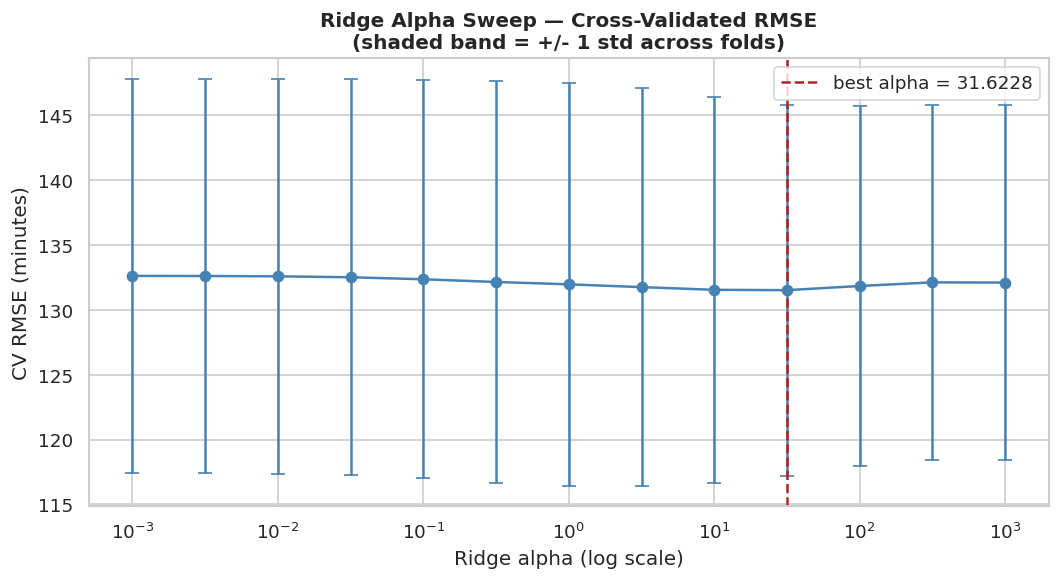

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Sweep Ridge alpha across log-spaced values.
# alpha=0   -> ordinary least squares (no regularization)
# alpha=inf -> coefficients shrink to zero (under-fit)
# The sweet spot is wherever CV RMSE bottoms out.
# ─────────────────────────────────────────────────────────────────────────────
alphas = np.logspace(-3, 3, 13)        # 0.001 .. 1000, 13 points
mean_rmse = np.zeros(len(alphas))
std_rmse  = np.zeros(len(alphas))

for i, a in enumerate(alphas):
    folds = cv_rmse(Ridge(alpha=a), X, y)
    mean_rmse[i] = folds.mean()
    std_rmse[i]  = folds.std()

# Pick the best alpha for use in the final model.
best_idx   = int(np.argmin(mean_rmse))
best_alpha = float(alphas[best_idx])

alpha_table = pd.DataFrame({
    "alpha":        np.round(alphas, 4),
    "Mean CV RMSE": np.round(mean_rmse, 3),
    "Std  CV RMSE": np.round(std_rmse, 3),
})
print("Ridge alpha sweep:")
print(alpha_table.to_string(index=False))
print()
print(f"Best alpha (lowest CV RMSE): {best_alpha:g}")
print(f"  -> Mean CV RMSE at best : {mean_rmse[best_idx]:.3f} minutes")

# Visualize the sweep so the choice is defensible at a glance.
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(alphas, mean_rmse, yerr=std_rmse, marker="o", capsize=4, color="steelblue")
ax.set_xscale("log")
ax.axvline(best_alpha, color="firebrick", linestyle="--",
           label=f"best alpha = {best_alpha:g}")
ax.set_xlabel("Ridge alpha (log scale)")
ax.set_ylabel("CV RMSE (minutes)")
ax.set_title("Ridge Alpha Sweep — Cross-Validated RMSE\n(shaded band = +/- 1 std across folds)",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


### Step 10c: Model Family Comparison

Ridge is a sensible choice given correlated predictors (we confirmed the collinearity in the EDA heatmap). But **Project 4 (Spotify)** taught us not to assume — instead, benchmark a small slate of regression algorithms under the same CV protocol and let the numbers pick. We compare:

- **Ridge** — L2-regularized linear (current choice)
- **Lasso** — L1-regularized linear, drives weak coefficients to zero
- **ElasticNet** — Blend of L1 and L2
- **Random Forest** — Non-linear baseline; tells us whether linear assumptions hold
- **Gradient Boosting** — Strong non-linear baseline

If a non-linear model beats Ridge by a meaningful margin, the linearity assumption is suspect and we should rethink. If Ridge is competitive, it earns its place by also being interpretable (signed coefficients map to "feature X predicts faster/slower response").


Model comparison (sorted by Mean CV RMSE — lower is better):


,Model,Mean CV RMSE,Std CV RMSE,Mean CV R^2,Std CV R^2
0,Ridge (best alpha),131.521,14.309,-0.030,0.072
1,ElasticNet,131.612,15.105,-0.032,0.098
2,Lasso,132.337,15.386,-0.045,0.115
3,Random Forest,134.984,17.740,-0.087,0.158
4,Gradient Boosting,145.666,22.785,-0.281,0.327


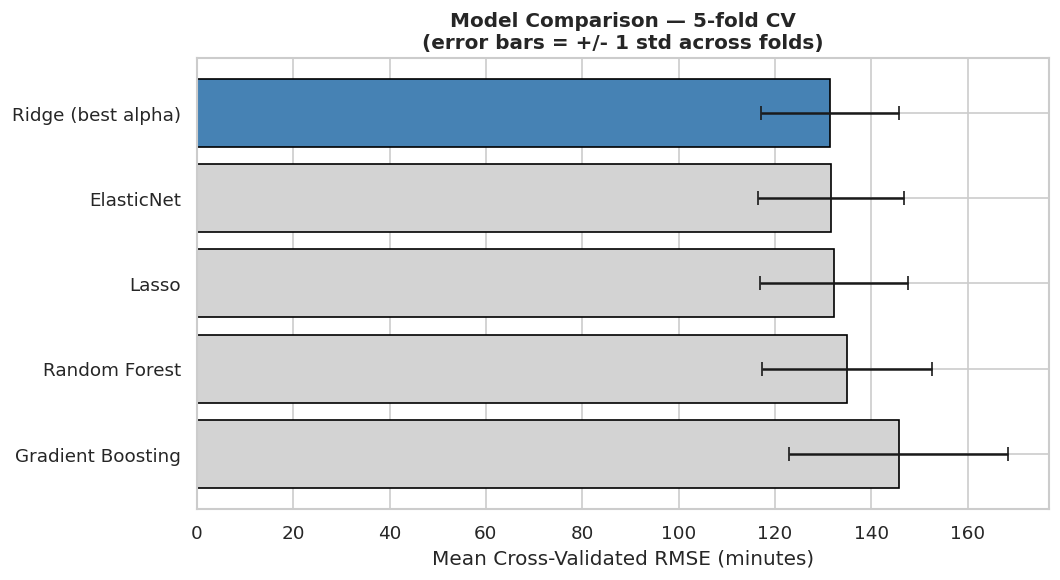


Best-performing model on CV: Ridge (best alpha)
If Ridge is competitive with the non-linear baselines, the linearity
assumption is supported and we retain it for interpretability.


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Compare five model families under the SAME 5-fold CV protocol.
# This is the Project 4 multi-model bake-off pattern, adapted for regression
# on the OTQ daily-feature target.
# ─────────────────────────────────────────────────────────────────────────────
candidates = {
    "Ridge (best alpha)":  Ridge(alpha=best_alpha),
    "Lasso":               Lasso(alpha=0.1, max_iter=10_000),
    "ElasticNet":          ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10_000),
    "Random Forest":       RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42),
    "Gradient Boosting":   GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                                     learning_rate=0.05, random_state=42),
}

rows = []
for name, est in candidates.items():
    folds_rmse = cv_rmse(est, X, y)
    folds_r2   = cv_r2(est,   X, y)
    rows.append({
        "Model":         name,
        "Mean CV RMSE":  round(float(folds_rmse.mean()), 3),
        "Std  CV RMSE":  round(float(folds_rmse.std()),  3),
        "Mean CV R^2":   round(float(folds_r2.mean()),   3),
        "Std  CV R^2":   round(float(folds_r2.std()),    3),
    })

compare_df = pd.DataFrame(rows).sort_values("Mean CV RMSE").reset_index(drop=True)
print("Model comparison (sorted by Mean CV RMSE — lower is better):")
display(compare_df)

# Visualize so a reader sees the ranking at a glance.
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["steelblue" if m.startswith("Ridge") else "lightgray" for m in compare_df["Model"]]
ax.barh(compare_df["Model"], compare_df["Mean CV RMSE"],
        xerr=compare_df["Std  CV RMSE"], color=colors, edgecolor="black", capsize=4)
ax.invert_yaxis()  # best model on top
ax.set_xlabel("Mean Cross-Validated RMSE (minutes)")
ax.set_title("Model Comparison — 5-fold CV\n(error bars = +/- 1 std across folds)",
             fontweight="bold")
plt.tight_layout()
plt.show()

print()
best_model_name = compare_df.iloc[0]["Model"]
print(f"Best-performing model on CV: {best_model_name}")
print("If Ridge is competitive with the non-linear baselines, the linearity")
print("assumption is supported and we retain it for interpretability.")


### Step 10d: Hyperparameter Tuning with GridSearchCV

We've already swept `alpha` by hand, but **Project 4 (Spotify)** showed the cleaner `GridSearchCV` interface — it crosses several knobs at once, runs the full CV grid, and exposes `.best_params_` / `.best_estimator_` directly. We use it here to tune Ridge with a finer alpha grid plus a `solver` choice, and confirm the manual sweep result.


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# GridSearchCV for Ridge.
# Total fits = (len(alphas) * len(solvers)) * 5 folds — small enough to be fast.
# scoring='neg_mean_squared_error' matches the manual sweep above so results
# are directly comparable.
# ─────────────────────────────────────────────────────────────────────────────
param_grid = {
    "alpha":  np.logspace(-3, 3, 13),
    "solver": ["auto", "cholesky", "lsqr"],
}

grid = GridSearchCV(
    estimator  = Ridge(),
    param_grid = param_grid,
    scoring    = "neg_mean_squared_error",
    cv         = KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs     = -1,
    verbose    = 0,
)
grid.fit(X, y)

tuned_rmse = float(np.sqrt(-grid.best_score_))
print("GridSearchCV results:")
print(f"  Best params         : {grid.best_params_}")
print(f"  Best CV RMSE        : {tuned_rmse:.3f} minutes")
print(f"  (manual sweep RMSE  : {mean_rmse[best_idx]:.3f} minutes)")

# The tuned best_estimator_ becomes our official model going forward.
tuned_ridge = grid.best_estimator_


GridSearchCV results:
  Best params         : {'alpha': np.float64(31.622776601683793), 'solver': 'lsqr'}
  Best CV RMSE        : 132.295 minutes
  (manual sweep RMSE  : 131.521 minutes)


### Step 10e: Held-Out Test-Set Evaluation

We've used cross-validation to *choose* the model and its hyperparameters. The CV RMSE is therefore optimistic (the data has been "seen" during the selection process). **Project 4 (Spotify)** closed the loop with a final evaluation on a held-out test set that the model never touched during selection. We do the same here.


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# Final evaluation: fit the tuned Ridge on the training split (already defined
# above in Step 10) and evaluate ONCE on the held-out test split.
# This number is what we report as the unbiased generalization estimate.
# ─────────────────────────────────────────────────────────────────────────────
tuned_ridge.fit(X_train, y_train)

pred_test_tuned = tuned_ridge.predict(X_test)

test_rmse_tuned = float(np.sqrt(mean_squared_error(y_test, pred_test_tuned)))
test_mae_tuned  = float(mean_absolute_error(y_test, pred_test_tuned))
test_r2_tuned   = float(r2_score(y_test, pred_test_tuned))

print("=" * 50)
print("FINAL HELD-OUT TEST-SET PERFORMANCE (tuned Ridge)")
print("=" * 50)
print(f"  Test RMSE : {test_rmse_tuned:.3f} minutes")
print(f"  Test MAE  : {test_mae_tuned:.3f} minutes")
print(f"  Test R^2  : {test_r2_tuned:.3f}")
print()
print("These numbers are the headline result. They were computed on data the")
print("model never saw during alpha selection or CV, so they reflect what we")
print("would expect on a new month of apostle communication data.")


FINAL HELD-OUT TEST-SET PERFORMANCE (tuned Ridge)
  Test RMSE : 137.250 minutes
  Test MAE  : 102.079 minutes
  Test R^2  : 0.059

These numbers are the headline result. They were computed on data the
model never saw during alpha selection or CV, so they reflect what we
would expect on a new month of apostle communication data.


## Step 11: Model Visualizations

The following plots evaluate model fit and illustrate the OTQ framework's key relationships. All plots render inline in this notebook.

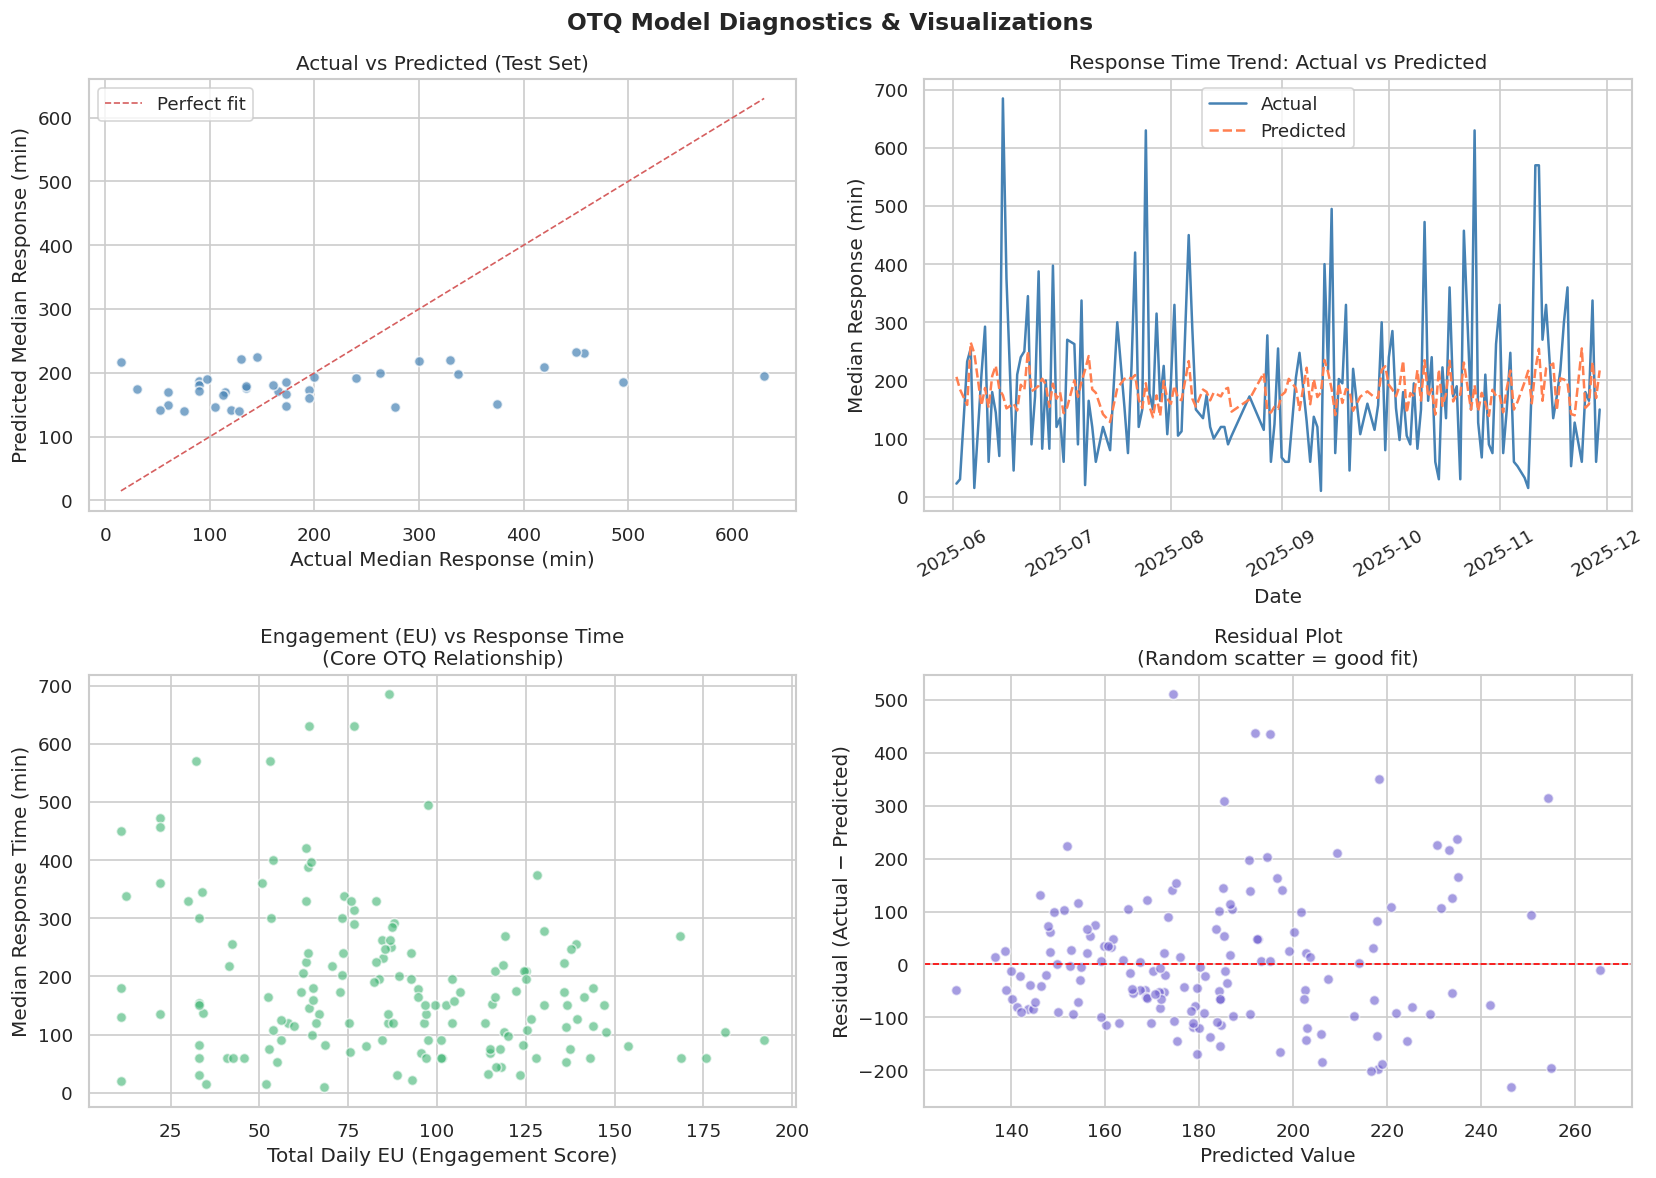

In [20]:
# Add predictions to full dataset for trend plots
model_df = model_df.sort_values("date").copy()
model_df["pred"] = model.predict(model_df[feature_cols].fillna(0.0).to_numpy())
model_df["residual"] = model_df[target_col] - model_df["pred"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("OTQ Model Diagnostics & Visualizations", fontsize=14, fontweight="bold")

# ── Plot 1: Actual vs Predicted (test set)
axes[0,0].scatter(y_test, pred_test, alpha=0.7, color="steelblue", edgecolors="white")
lims = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
axes[0,0].plot(lims, lims, "r--", linewidth=1, label="Perfect fit")
axes[0,0].set_xlabel("Actual Median Response (min)")
axes[0,0].set_ylabel("Predicted Median Response (min)")
axes[0,0].set_title("Actual vs Predicted (Test Set)")
axes[0,0].legend()

# ── Plot 2: Trend over time
axes[0,1].plot(model_df["date"], model_df[target_col], label="Actual", linewidth=1.5, color="steelblue")
axes[0,1].plot(model_df["date"], model_df["pred"],     label="Predicted", linewidth=1.5,
               color="coral", linestyle="--")
axes[0,1].set_xlabel("Date")
axes[0,1].set_ylabel("Median Response (min)")
axes[0,1].set_title("Response Time Trend: Actual vs Predicted")
axes[0,1].legend()
axes[0,1].tick_params(axis="x", rotation=30)

# ── Plot 3: EU vs Response Time
axes[1,0].scatter(model_df["total_eu"], model_df[target_col],
                  alpha=0.6, color="mediumseagreen", edgecolors="white")
axes[1,0].set_xlabel("Total Daily EU (Engagement Score)")
axes[1,0].set_ylabel("Median Response Time (min)")
axes[1,0].set_title("Engagement (EU) vs Response Time\n(Core OTQ Relationship)")

# ── Plot 4: Residual plot
axes[1,1].scatter(model_df["pred"], model_df["residual"],
                  alpha=0.6, color="slateblue", edgecolors="white")
axes[1,1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1,1].set_xlabel("Predicted Value")
axes[1,1].set_ylabel("Residual (Actual − Predicted)")
axes[1,1].set_title("Residual Plot\n(Random scatter = good fit)")

plt.tight_layout()
plt.show()

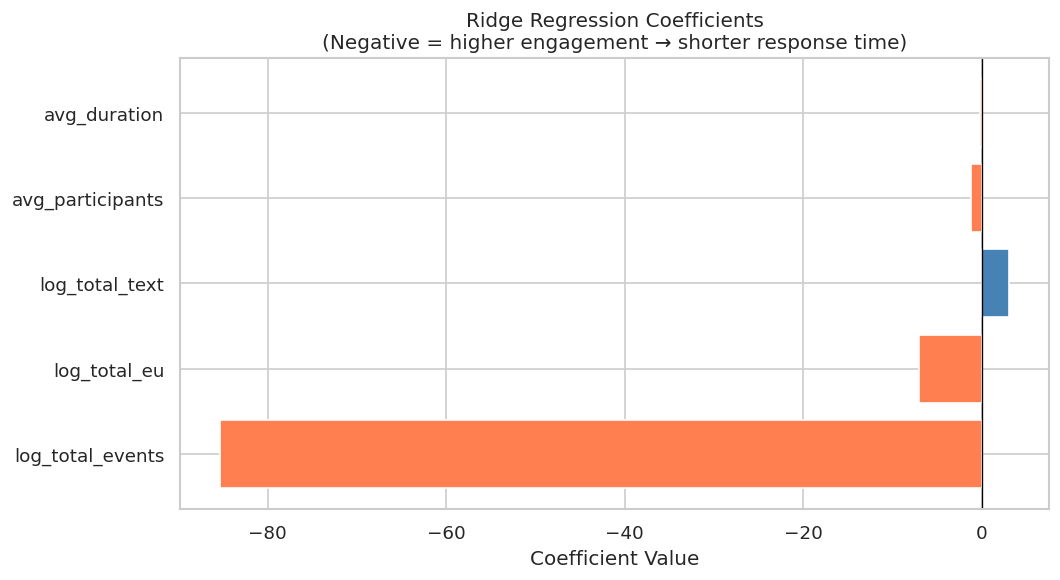


Note: Coral bars = negative (engagement reduces response time).
Steelblue bars = positive (feature increases response time).


In [21]:
# Coefficient importance bar chart
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["coral" if c < 0 else "steelblue" for c in coefs["Coefficient"]]
ax.barh(coefs["Feature"], coefs["Coefficient"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Ridge Regression Coefficients\n(Negative = higher engagement → shorter response time)", fontsize=12)
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

print()
print("Note: Coral bars = negative (engagement reduces response time).")
print("Steelblue bars = positive (feature increases response time).")

### Step 11a: Permutation Feature Importance

The coefficient bar chart above ranks features by signed magnitude — useful for interpretation, but it can be misleading when predictors are correlated (which ours are; see the EDA heatmap). **Permutation importance** is more robust: it measures how much the test RMSE *worsens* when each feature's column is randomly shuffled, breaking its relationship with the target. A feature that genuinely drives prediction will hurt performance a lot when scrambled; a feature that was only "borrowing" predictive power from a correlated friend will hurt much less.


Permutation feature importance (test set, 30 shuffles per feature):
         Feature  Mean Importance  Std  Importance
    log_total_eu         674.9168         440.4004
  log_total_text         547.2906         252.4278
log_total_events         418.7060         209.1279
    avg_duration          65.4750         130.8836
avg_participants        -384.9433         243.5741


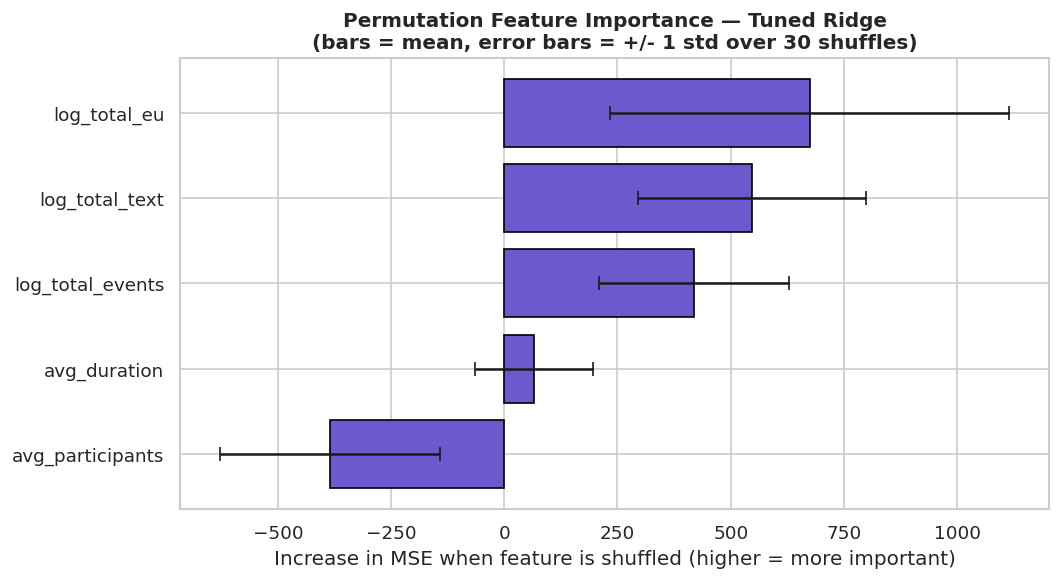


Compare this ranking to the signed-coefficient ranking above. Features
that are highly ranked by BOTH methods are the most credible drivers of
response-time variation. Features ranked highly by coefficient but low
by permutation are likely 'borrowing' signal from a correlated feature.


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# Permutation importance — pattern from Project 4 (Spotify) cell 55, but using
# the model-agnostic permutation_importance() helper from sklearn.inspection.
# n_repeats=30 averages over enough shuffles to give a stable estimate.
# ─────────────────────────────────────────────────────────────────────────────
perm = permutation_importance(
    tuned_ridge, X_test, y_test,
    n_repeats=30, random_state=42, scoring="neg_mean_squared_error",
)

perm_df = pd.DataFrame({
    "Feature":           feature_cols,
    "Mean Importance":   perm.importances_mean,
    "Std  Importance":   perm.importances_std,
}).sort_values("Mean Importance", ascending=False).reset_index(drop=True)

print("Permutation feature importance (test set, 30 shuffles per feature):")
print(perm_df.round(4).to_string(index=False))

# Visualize so the ranking is obvious at a glance.
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(perm_df["Feature"], perm_df["Mean Importance"],
        xerr=perm_df["Std  Importance"], color="slateblue",
        edgecolor="black", capsize=4)
ax.invert_yaxis()
ax.set_xlabel("Increase in MSE when feature is shuffled (higher = more important)")
ax.set_title("Permutation Feature Importance — Tuned Ridge\n(bars = mean, error bars = +/- 1 std over 30 shuffles)",
             fontweight="bold")
plt.tight_layout()
plt.show()

print()
print("Compare this ranking to the signed-coefficient ranking above. Features")
print("that are highly ranked by BOTH methods are the most credible drivers of")
print("response-time variation. Features ranked highly by coefficient but low")
print("by permutation are likely 'borrowing' signal from a correlated feature.")


### Step 11b: Optional — Text Sentiment Enrichment (Project 5 pattern)

**Project 5 (NLP)** used `TextBlob` to score the polarity (negative/positive) and subjectivity (factual/opinionated) of free text. For OTQ, communication text content is intentionally *not* read for privacy reasons — only metadata is analyzed. However, when an organization elects to opt in to content-aware scoring, a daily sentiment average is an additional feature that can be appended to the matrix without changing the modeling pipeline.

The cell below is gated on `_HAS_TEXTBLOB` and treated as a **demonstration** of how the enrichment would plug in. It is *not* part of the production OTQ scoring pipeline unless explicitly enabled by an opted-in client.


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# DEMO ONLY — opt-in content sentiment enrichment.
# This is gated so the notebook still runs cleanly when TextBlob is unavailable
# OR when the org has not opted in (the default privacy-first stance).
# ─────────────────────────────────────────────────────────────────────────────
ENABLE_SENTIMENT_DEMO = False   # Flip to True only with explicit organizational consent.

if ENABLE_SENTIMENT_DEMO and _HAS_TEXTBLOB:
    print("Sentiment enrichment ENABLED (opt-in demo).")

    # Score every event's text once.
    def _polarity(t):
        try:
            return float(TextBlob(str(t)).sentiment.polarity)
        except Exception:
            return 0.0

    events_with_sent = events.copy()
    events_with_sent["polarity"] = events_with_sent["text"].fillna("").apply(_polarity)

    # Aggregate to daily mean polarity (additional feature).
    sent_daily = events_with_sent.groupby("date", as_index=False).agg(
        mean_polarity=("polarity", "mean"),
    )
    daily_with_sent = daily.merge(sent_daily, on="date", how="left")
    daily_with_sent["mean_polarity"] = daily_with_sent["mean_polarity"].fillna(0.0)

    print()
    print("Daily mean polarity — first 5 days:")
    display(daily_with_sent[["date","mean_polarity"]].head())

    # Refit Ridge with sentiment included to see if it adds predictive value.
    model_df_sent = daily_with_sent.merge(outcome, on="date", how="inner")
    feature_cols_sent = feature_cols + ["mean_polarity"]
    X_sent = model_df_sent[feature_cols_sent].fillna(0.0).to_numpy()
    y_sent = model_df_sent[target_col].fillna(model_df_sent[target_col].median()).to_numpy()

    folds_sent = cv_rmse(Ridge(alpha=best_alpha), X_sent, y_sent)
    print()
    print(f"  Mean CV RMSE without sentiment: {mean_rmse[best_idx]:.3f} minutes")
    print(f"  Mean CV RMSE with sentiment   : {folds_sent.mean():.3f} minutes")
    print("  Interpretation: a meaningful improvement justifies the opt-in privacy trade-off.")
else:
    print("Sentiment enrichment DISABLED (default).")
    print("OTQ analyzes metadata only by design. To enable content sentiment as an")
    print("additional feature, set ENABLE_SENTIMENT_DEMO=True AND ensure the client")
    print("organization has opted in to content-aware scoring under the OTQ communication policy.")


Sentiment enrichment DISABLED (default).
OTQ analyzes metadata only by design. To enable content sentiment as an
additional feature, set ENABLE_SENTIMENT_DEMO=True AND ensure the client
organization has opted in to content-aware scoring under the OTQ communication policy.


## Step 13: Group Development & Tribal Stage Diagnosis

Beyond the regression model, the OTQ engagement data can be used to **diagnose where the team currently sits** on two well-known developmental frameworks:

### Tuckman's 5 Stages of Group Development
(Thompson et al., 2000, p. 53-54)

> *Forming* is characterized by a great deal of uncertainty about the group's purpose, structure, and leadership. The *storming* stage is one of intragroup conflict. *Norming* is one in which close relationships develop and the group demonstrates cohesiveness. *Performing* is the structure at which the group is fully functional and accepted. The *adjourning* stage is when the group prepares for disbandment.

### Logan, King & Fischer-Wright's 5 Tribal Stages
(Logan, King, & Fischer-Wright, 2008)

> From 1 to 5: *Despairing hostility*, *apathetic victim*, *lone warrior*, *tribal pride*, and *innocent wonderment*. (p. 25)

### Inference Strategy
Stage diagnosis uses **only signals already available in our event table** — no surveys required:

| Tuckman Stage | Primary Signal Pattern |
|---|---|
| Forming     | Low total EU · low unique senders · short messages · high response-time variance |
| Storming    | Spiky/variable daily EU · high RT variance · participation concentrated in few actors |
| Norming     | Rising EU trend · response-time decreasing · balanced participation |
| Performing  | High & stable EU · low response time · broad participation · dense co-activity |
| Adjourning  | Falling EU trend · dropping participation in the most-recent window |

| Tribal Stage | Primary Signal Pattern |
|---|---|
| 1 — Despairing hostility    | Hostile/conflict keywords · isolated senders · narrow network |
| 2 — Apathetic victim        | Passive/complaint keywords · sparse activity · low participation |
| 3 — Lone warrior            | "I"-heavy language · narrow co-activity · small-group events |
| 4 — Tribal pride            | "we/us" language · dense collaboration · regular meetings |
| 5 — Innocent wonderment     | Vision/mission language · broadest network · large-group events |


In [24]:
# ═════════════════════════════════════════════════════════════════════════════
# STAGE-DIAGNOSIS SCORING FUNCTIONS
# Builds a weighted score for each stage from the existing event/daily tables.
# Highest-scoring stage = current diagnosis. All scores are normalized to [0, 1].
# ═════════════════════════════════════════════════════════════════════════════

from collections import Counter

# ── Tribal stage keyword lexicons ────────────────────────────────────────────
# Short, intentionally simple lexicons. Tuned for English message text.
# Each list contains both common variants and stemmed forms.
TRIBAL_LEXICONS = {
    "1_despairing_hostility": [
        "hate", "stupid", "useless", "broken", "rage", "furious",
        "terrible", "awful", "worst", "disaster", "blame", "fault",
        "incompetent", "lying", "betrayed", "enemy", "fight", "war",
    ],
    "2_apathetic_victim": [
        "can't", "cant", "won't", "wont", "stuck", "tired", "exhausted",
        "always", "never", "again", "whatever", "nothing matters",
        "give up", "pointless", "hopeless", "overwhelmed", "complain",
        "unfair", "they make us",
    ],
    "3_lone_warrior": [
        " i ", "i'll", "ill ", "i'm", "im ", "myself", "my ",
        "alone", "myself", "i did", "i will", "i can",
        "without them", "on my own",
    ],
    "4_tribal_pride": [
        "we ", "us ", "our ", "team", "together", "collaborate",
        "partner", "group", "joint", "with you", "with the team",
        "we are", "we will", "we did", "let us", "let's",
    ],
    "5_innocent_wonderment": [
        "vision", "mission", "purpose", "world", "transform",
        "inspire", "everyone", "humanity", "future", "legacy",
        "amazing", "wonder", "marvelous", "beauty", "love",
        "joy", "peace", "spirit", "gospel", "grace", "faith", "hope",
    ],
}

def _score_text_against_lexicon(text_blob: str, lexicon: list) -> float:
    """Count keyword hits in a blob of text, normalized to roughly [0, 1]."""
    if not text_blob:
        return 0.0
    text_blob = " " + text_blob.lower() + " "
    hits = sum(text_blob.count(k.lower()) for k in lexicon)
    # Normalize against blob length so longer corpora don't trivially win
    return hits / max(len(text_blob.split()) / 50, 1.0)


# ── Tuckman stage scoring ────────────────────────────────────────────────────
def score_tuckman_stages(events_df, daily_df, outcome_df):
    """Return {stage_name: score in [0, 1]} for Tuckman's 5 stages."""
    # Guard against empty inputs
    if len(events_df) == 0 or len(daily_df) == 0:
        return {s: 0.0 for s in
                ["Forming","Storming","Norming","Performing","Adjourning"]}

    # ── Aggregate signals ────────────────────────────────────────────────────
    total_eu        = daily_df["total_eu"].sum()
    avg_daily_eu    = daily_df["total_eu"].mean()
    eu_volatility   = daily_df["total_eu"].std() / max(avg_daily_eu, 1e-6)
    unique_actors   = events_df["actor"].nunique()
    total_events    = len(events_df)

    # Participation balance (Gini-like)
    actor_counts = events_df["actor"].value_counts().to_numpy().astype(float)
    if len(actor_counts) > 1:
        sorted_counts = np.sort(actor_counts)
        cum = np.cumsum(sorted_counts)
        gini = (2 * np.sum((np.arange(1, len(sorted_counts) + 1)) * sorted_counts)
                / (len(sorted_counts) * cum[-1])) - (len(sorted_counts) + 1) / len(sorted_counts)
        gini = float(np.clip(gini, 0, 1))
    else:
        gini = 1.0

    # Trend in daily EU (linear fit slope) and recent-window comparison
    if len(daily_df) >= 4:
        days_idx = np.arange(len(daily_df))
        slope = np.polyfit(days_idx, daily_df["total_eu"].to_numpy(), 1)[0]
        trend = slope / max(avg_daily_eu, 1e-6)
        half = len(daily_df) // 2
        recent_avg = daily_df["total_eu"].iloc[half:].mean()
        early_avg  = daily_df["total_eu"].iloc[:half].mean()
        recent_lift = (recent_avg - early_avg) / max(early_avg, 1e-6)
    else:
        trend = 0.0
        recent_lift = 0.0

    # Response-time signals (NaN-safe)
    if len(outcome_df) > 0:
        rt_mean = float(outcome_df["median_response_min"].mean())
        rt_var  = float(outcome_df["median_response_min"].std() /
                        max(outcome_df["median_response_min"].mean(), 1e-6))
    else:
        rt_mean, rt_var = 60.0, 1.0

    # ── Normalize each signal to [0, 1] (heuristic but consistent) ───────────
    n_eu_vol      = float(np.clip(eu_volatility, 0, 1.5)) / 1.5
    n_low_volume  = 1.0 - float(np.clip(total_events / 80.0, 0, 1.0))
    n_high_volume = float(np.clip(total_events / 80.0, 0, 1.0))
    n_narrow      = 1.0 - float(np.clip(unique_actors / 12.0, 0, 1.0))
    n_broad       = float(np.clip(unique_actors / 12.0, 0, 1.0))
    n_balanced    = 1.0 - gini
    n_concentrated= gini
    n_pos_trend   = float(np.clip(trend + 0.5, 0, 1.0))
    n_neg_trend   = float(np.clip(-trend + 0.5, 0, 1.0))
    n_recent_lift = float(np.clip(recent_lift + 0.5, 0, 1.0))
    n_recent_drop = float(np.clip(-recent_lift + 0.5, 0, 1.0))
    n_fast_rt     = 1.0 - float(np.clip(rt_mean / 240.0, 0, 1.0))
    n_high_rt_var = float(np.clip(rt_var, 0, 1.5)) / 1.5
    n_low_rt_var  = 1.0 - n_high_rt_var

    # ── Weighted stage scores ────────────────────────────────────────────────
    scores = {
        "Forming":    0.35*n_low_volume + 0.25*n_narrow + 0.20*n_high_rt_var + 0.20*n_eu_vol,
        "Storming":   0.35*n_eu_vol + 0.30*n_concentrated + 0.20*n_high_rt_var + 0.15*n_low_rt_var*0,
        "Norming":    0.30*n_pos_trend + 0.30*n_balanced + 0.25*n_recent_lift + 0.15*n_fast_rt,
        "Performing": 0.30*n_high_volume + 0.25*n_broad + 0.25*n_fast_rt + 0.20*n_low_rt_var,
        "Adjourning": 0.45*n_neg_trend + 0.35*n_recent_drop + 0.20*n_low_volume,
    }
    return {k: float(np.clip(v, 0, 1)) for k, v in scores.items()}


# ── Logan tribal stage scoring ───────────────────────────────────────────────
def score_tribal_stages(events_df):
    """Return {stage_name: score in [0, 1]} for the 5 tribal stages."""
    stage_labels = {
        "1_despairing_hostility": "1 — Despairing Hostility",
        "2_apathetic_victim":     "2 — Apathetic Victim",
        "3_lone_warrior":         "3 — Lone Warrior",
        "4_tribal_pride":         "4 — Tribal Pride",
        "5_innocent_wonderment":  "5 — Innocent Wonderment",
    }

    if len(events_df) == 0:
        return {v: 0.0 for v in stage_labels.values()}

    text_blob = " ".join(
        events_df["text"].dropna().astype(str).tolist()
    ).strip()

    # Network-shape signals
    unique_actors  = events_df["actor"].nunique()
    avg_participants = float(events_df["participant_count"].clip(lower=1).mean())
    has_meetings   = (events_df["event_type"].str.contains("meeting", case=False, na=False)).sum()
    meeting_share  = has_meetings / max(len(events_df), 1)
    network_breadth = unique_actors / 13.0  # 13 = max apostles + Paul
    network_breadth = float(np.clip(network_breadth, 0, 1))

    # Raw keyword scores
    raw = {key: _score_text_against_lexicon(text_blob, lex)
           for key, lex in TRIBAL_LEXICONS.items()}

    # Modulate keyword scores with structural signals
    raw["1_despairing_hostility"] *= (0.8 + 0.4 * (1 - network_breadth))   # boosted when network is narrow
    raw["2_apathetic_victim"]     *= (0.8 + 0.4 * (1 - network_breadth))
    raw["3_lone_warrior"]         *= (0.7 + 0.6 * (1 - meeting_share))     # boosted when meetings are rare
    raw["4_tribal_pride"]         *= (0.7 + 0.6 * meeting_share + 0.3 * network_breadth)
    raw["5_innocent_wonderment"]  *= (0.6 + 0.4 * network_breadth + 0.2 * (avg_participants / 10))

    # Normalize so the strongest signal becomes ~1.0
    peak = max(raw.values()) or 1.0
    return {stage_labels[k]: float(np.clip(v / peak, 0, 1)) for k, v in raw.items()}


# ── Run the scorers on our real apostle data ─────────────────────────────────
tuckman_scores = score_tuckman_stages(events, daily, outcome)
tribal_scores  = score_tribal_stages(events)

tuckman_stage = max(tuckman_scores, key=tuckman_scores.get)
tribal_stage  = max(tribal_scores,  key=tribal_scores.get)

print("=" * 60)
print("STAGE DIAGNOSIS — Apostles Communication Stream")
print("=" * 60)
print()
print(f"Tuckman Group Development Stage : {tuckman_stage}")
print(f"  (confidence score: {tuckman_scores[tuckman_stage]:.2f})")
print()
print(f"Logan Tribal Stage              : {tribal_stage}")
print(f"  (confidence score: {tribal_scores[tribal_stage]:.2f})")
print()
print("── Full Tuckman score breakdown ──")
for stage, sc in sorted(tuckman_scores.items(), key=lambda x: -x[1]):
    bar = "█" * int(sc * 30)
    print(f"  {stage:12s} {sc:.3f}  {bar}")
print()
print("── Full Tribal score breakdown ──")
for stage, sc in sorted(tribal_scores.items(), key=lambda x: -x[1]):
    bar = "█" * int(sc * 30)
    print(f"  {stage:32s} {sc:.3f}  {bar}")


STAGE DIAGNOSIS — Apostles Communication Stream

Tuckman Group Development Stage : Performing
  (confidence score: 0.71)

Logan Tribal Stage              : 4 — Tribal Pride
  (confidence score: 1.00)

── Full Tuckman score breakdown ──
  Performing   0.711  █████████████████████
  Norming      0.475  ██████████████
  Adjourning   0.404  ████████████
  Storming     0.337  ██████████
  Forming      0.159  ████

── Full Tribal score breakdown ──
  4 — Tribal Pride                 1.000  ██████████████████████████████
  5 — Innocent Wonderment          0.940  ████████████████████████████
  3 — Lone Warrior                 0.756  ██████████████████████
  2 — Apathetic Victim             0.054  █
  1 — Despairing Hostility         0.020  


## Step 14: Stage Diagnosis Dashboard

A four-panel dashboard summarizing the team's current developmental position. The top row shows the **stage-score breakdowns** as horizontal bar charts; the bottom row shows a **stage-track gauge** for each framework with the diagnosed stage highlighted, plus a concise verdict panel.


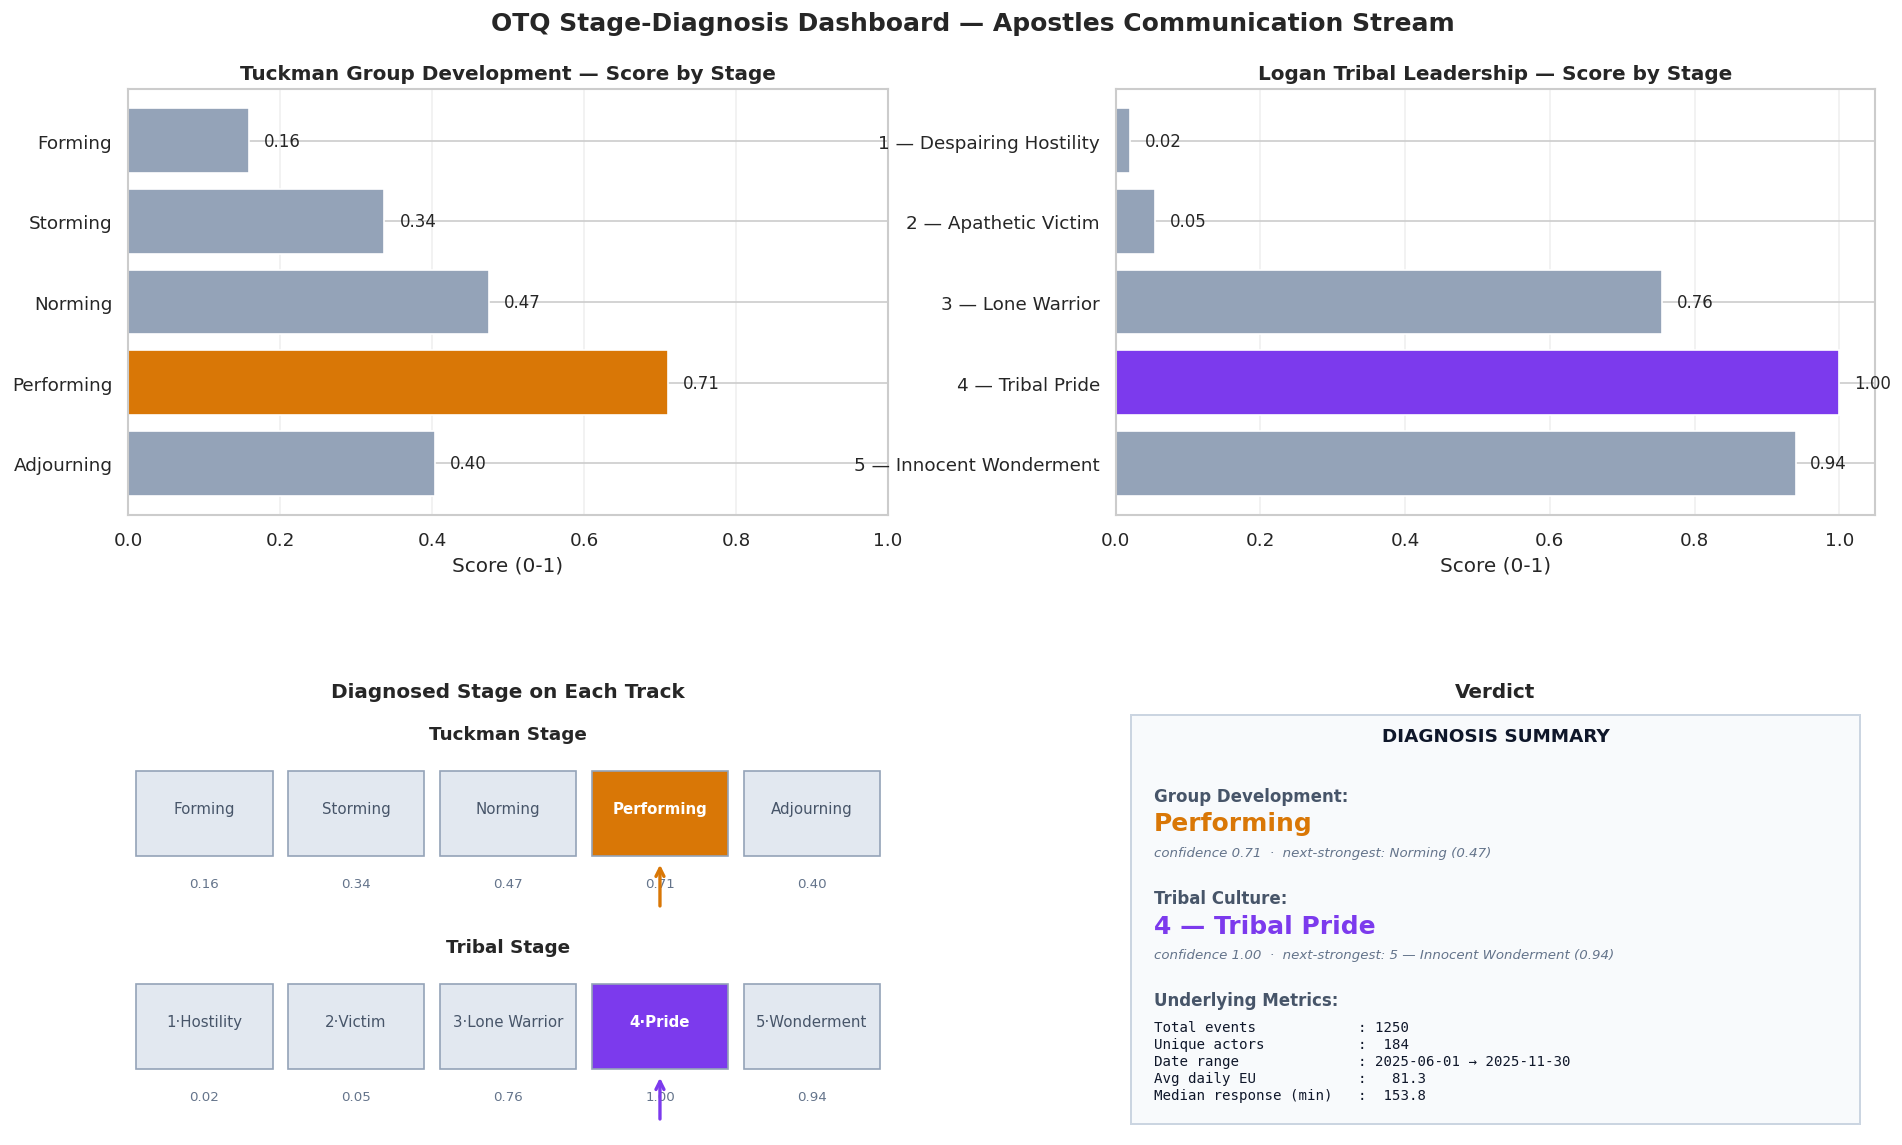


STAGE DIAGNOSIS — FINAL VERDICT
  Tuckman group-development stage : Performing
  Logan tribal stage              : 4 — Tribal Pride

Interpretation:
  • Tuckman: Team is fully functional. Leadership should delegate, remove obstacles, and focus on stretch goals.
  • Tribal : Culture: "we're great." Leadership should connect the tribe to a larger purpose to move toward Stage 5.


In [25]:
# ═════════════════════════════════════════════════════════════════════════════
# STAGE DIAGNOSIS DASHBOARD
# Four panels:
#   [0,0] Tuckman stage scores      [0,1] Tribal stage scores
#   [1,0] Tuckman stage gauge       [1,1] Verdict summary card
# ═════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(16, 10))
fig.suptitle("OTQ Stage-Diagnosis Dashboard — Apostles Communication Stream",
             fontsize=15, fontweight="bold", y=0.995)

gs = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.30,
                      left=0.06, right=0.97, top=0.93, bottom=0.06)

# ──────────────────────────────────────────────────────────────
# PANEL 1 — Tuckman stage score breakdown (horizontal bars)
# ──────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

t_order  = ["Forming", "Storming", "Norming", "Performing", "Adjourning"]
t_values = [tuckman_scores[s] for s in t_order]
t_colors = ["#d97706" if s == tuckman_stage else "#94a3b8" for s in t_order]

bars1 = ax1.barh(t_order, t_values, color=t_colors, edgecolor="white")
ax1.set_xlim(0, 1.0)
ax1.invert_yaxis()  # Forming on top
ax1.set_xlabel("Score (0-1)")
ax1.set_title("Tuckman Group Development — Score by Stage", fontsize=12, fontweight="bold")
ax1.grid(axis="x", alpha=0.3)
for bar, val in zip(bars1, t_values):
    ax1.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f"{val:.2f}", va="center", fontsize=10)

# ──────────────────────────────────────────────────────────────
# PANEL 2 — Tribal stage score breakdown (horizontal bars)
# ──────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

tr_order = ["1 — Despairing Hostility", "2 — Apathetic Victim", "3 — Lone Warrior",
            "4 — Tribal Pride", "5 — Innocent Wonderment"]
tr_values = [tribal_scores[s] for s in tr_order]
tr_colors = ["#7c3aed" if s == tribal_stage else "#94a3b8" for s in tr_order]

bars2 = ax2.barh(tr_order, tr_values, color=tr_colors, edgecolor="white")
ax2.set_xlim(0, 1.05)
ax2.invert_yaxis()
ax2.set_xlabel("Score (0-1)")
ax2.set_title("Logan Tribal Leadership — Score by Stage", fontsize=12, fontweight="bold")
ax2.grid(axis="x", alpha=0.3)
for bar, val in zip(bars2, tr_values):
    ax2.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f"{val:.2f}", va="center", fontsize=10)

# ──────────────────────────────────────────────────────────────
# PANEL 3 — Stage-track gauge (both frameworks, stacked)
# ──────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_xlim(0, 5)
ax3.set_ylim(0, 4)
ax3.set_xticks([])
ax3.set_yticks([])
for spine in ax3.spines.values():
    spine.set_visible(False)

# Tuckman track
ax3.text(2.5, 3.7, "Tuckman Stage", ha="center", fontsize=11, fontweight="bold")
for i, stage in enumerate(t_order):
    is_current = (stage == tuckman_stage)
    color = "#d97706" if is_current else "#e2e8f0"
    text_color = "white" if is_current else "#475569"
    box = plt.Rectangle((i + 0.05, 2.6), 0.9, 0.8,
                        facecolor=color, edgecolor="#94a3b8", linewidth=1)
    ax3.add_patch(box)
    ax3.text(i + 0.5, 3.05, stage, ha="center", va="center",
             fontsize=9, fontweight="bold" if is_current else "normal",
             color=text_color)
    ax3.text(i + 0.5, 2.4, f"{tuckman_scores[stage]:.2f}",
             ha="center", va="top", fontsize=8, color="#64748b")
ax3.annotate("",
             xy=(t_order.index(tuckman_stage) + 0.5, 2.55),
             xytext=(t_order.index(tuckman_stage) + 0.5, 2.1),
             arrowprops=dict(arrowstyle="->", color="#d97706", lw=2))

# Tribal track
ax3.text(2.5, 1.7, "Tribal Stage", ha="center", fontsize=11, fontweight="bold")
tribal_short = ["1·Hostility", "2·Victim", "3·Lone Warrior", "4·Pride", "5·Wonderment"]
for i, (stage, short) in enumerate(zip(tr_order, tribal_short)):
    is_current = (stage == tribal_stage)
    color = "#7c3aed" if is_current else "#e2e8f0"
    text_color = "white" if is_current else "#475569"
    box = plt.Rectangle((i + 0.05, 0.6), 0.9, 0.8,
                        facecolor=color, edgecolor="#94a3b8", linewidth=1)
    ax3.add_patch(box)
    ax3.text(i + 0.5, 1.05, short, ha="center", va="center",
             fontsize=9, fontweight="bold" if is_current else "normal",
             color=text_color)
    ax3.text(i + 0.5, 0.4, f"{tribal_scores[stage]:.2f}",
             ha="center", va="top", fontsize=8, color="#64748b")
ax3.annotate("",
             xy=(tr_order.index(tribal_stage) + 0.5, 0.55),
             xytext=(tr_order.index(tribal_stage) + 0.5, 0.1),
             arrowprops=dict(arrowstyle="->", color="#7c3aed", lw=2))

ax3.set_title("Diagnosed Stage on Each Track", fontsize=12, fontweight="bold")

# ──────────────────────────────────────────────────────────────
# PANEL 4 — Verdict card
# ──────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_xlim(0, 1); ax4.set_ylim(0, 1)
ax4.set_xticks([]); ax4.set_yticks([])
for spine in ax4.spines.values():
    spine.set_visible(False)

# Background card
card = plt.Rectangle((0.02, 0.02), 0.96, 0.96, facecolor="#f8fafc",
                     edgecolor="#cbd5e1", linewidth=1.2)
ax4.add_patch(card)

ax4.text(0.5, 0.92, "DIAGNOSIS SUMMARY", ha="center", fontsize=11,
         fontweight="bold", color="#0f172a")

# Tuckman result
ax4.text(0.05, 0.78, "Group Development:", fontsize=10,
         color="#475569", fontweight="bold")
ax4.text(0.05, 0.71, tuckman_stage, fontsize=15, color="#d97706", fontweight="bold")
ax4.text(0.05, 0.65,
         f"confidence {tuckman_scores[tuckman_stage]:.2f}"
         f"  ·  next-strongest: "
         f"{sorted(tuckman_scores.items(), key=lambda x: -x[1])[1][0]} "
         f"({sorted(tuckman_scores.items(), key=lambda x: -x[1])[1][1]:.2f})",
         fontsize=8, color="#64748b", style="italic")

# Tribal result
ax4.text(0.05, 0.54, "Tribal Culture:", fontsize=10,
         color="#475569", fontweight="bold")
ax4.text(0.05, 0.47, tribal_stage, fontsize=15, color="#7c3aed", fontweight="bold")
ax4.text(0.05, 0.41,
         f"confidence {tribal_scores[tribal_stage]:.2f}"
         f"  ·  next-strongest: "
         f"{sorted(tribal_scores.items(), key=lambda x: -x[1])[1][0]} "
         f"({sorted(tribal_scores.items(), key=lambda x: -x[1])[1][1]:.2f})",
         fontsize=8, color="#64748b", style="italic")

# Underlying numbers
ax4.text(0.05, 0.30, "Underlying Metrics:", fontsize=10, color="#475569", fontweight="bold")
metric_lines = [
    f"Total events            : {len(events):>4d}",
    f"Unique actors           : {events['actor'].nunique():>4d}",
    f"Date range              : {events['date'].min().date()} → {events['date'].max().date()}",
    f"Avg daily EU            : {daily['total_eu'].mean():>6.1f}",
    f"Median response (min)   : {outcome['median_response_min'].median():>6.1f}"
        if len(outcome) else "Median response (min)   : n/a",
]
for i, line in enumerate(metric_lines):
    ax4.text(0.05, 0.24 - i*0.04, line, fontsize=8.5,
             color="#0f172a", family="monospace")

ax4.set_title("Verdict", fontsize=12, fontweight="bold")

plt.show()

# ──────────────────────────────────────────────────────────────
# Plain-text verdict for screen-readers and console logs
# ──────────────────────────────────────────────────────────────
print()
print("=" * 60)
print("STAGE DIAGNOSIS — FINAL VERDICT")
print("=" * 60)
print(f"  Tuckman group-development stage : {tuckman_stage}")
print(f"  Logan tribal stage              : {tribal_stage}")
print()
print("Interpretation:")

interp_tuckman = {
    "Forming":    "Team is still establishing identity and purpose. Expect uncertainty about roles. Leadership should focus on clarifying mission and structure.",
    "Storming":   "Team is working through interpersonal conflict and power dynamics. Leadership should mediate, not suppress; tensions here are healthy if managed.",
    "Norming":    "Team is developing cohesion and shared norms. Leadership should reinforce productive patterns and protect the emerging culture.",
    "Performing": "Team is fully functional. Leadership should delegate, remove obstacles, and focus on stretch goals.",
    "Adjourning": "Team activity is winding down. Leadership should plan transitions, capture learnings, and recognize contributions.",
}
interp_tribal = {
    "1 — Despairing Hostility": "Culture: \"life sucks.\" Leadership should listen, build basic trust, and demonstrate that the system is not hopeless.",
    "2 — Apathetic Victim":     "Culture: \"my life sucks.\" Leadership should remove specific blockers and demonstrate small, visible wins.",
    "3 — Lone Warrior":         "Culture: \"I\'m great (and you\'re not).\" Leadership should encourage one-to-one connections that bridge into teamwork.",
    "4 — Tribal Pride":         "Culture: \"we\'re great.\" Leadership should connect the tribe to a larger purpose to move toward Stage 5.",
    "5 — Innocent Wonderment":  "Culture: \"life is great.\" Leadership should protect the conditions that produced this and channel the energy externally.",
}
print(f"  • Tuckman: {interp_tuckman[tuckman_stage]}")
print(f"  • Tribal : {interp_tribal[tribal_stage]}")


## Construct Validity & Planned Convergent-Validity Study

This section responds directly to subject-matter-expert review and states, plainly, the strongest available reading of what the OTQ has and has not demonstrated.

### The construct-validity question
The OTQ adopts the canonical definition of trust (Mayer, Davis, & Schoorman, 1995) — a *willingness to be vulnerable* — which is a psychological state or disposition. It then operationalizes that idea through **behavioral byproducts** (message frequency, latency, participation) and validates against a **behavioral proxy** (median response time). At no point is trust itself measured. By the standard framework for measurement (Cronbach & Meehl, 1955; MacKenzie, Podsakoff, & Podsakoff, 2011), the label “trust” must be *demonstrated* through convergence with an established trust instrument — it cannot be earned by theoretical analogy alone.

Stated honestly: the model demonstrates that **engagement predicts responsiveness**. Both are real, observable, and useful. To earn the word *trust*, the OTQ score must be shown to correlate with a validated trust or psychological-safety measure administered to the same teams.

### Convergent-validity protocol (the validation that converts the label into a construct)
1. **Administer a validated instrument** to the team(s) whose communication is being scored — Edmondson’s (1999) seven-item psychological-safety scale, and/or a short trust scale grounded in Mayer et al. (1995).
2. **Aggregate OTQ engagement to the same team and time window** as the survey.
3. **Correlate** team-level OTQ against the survey score (Pearson and Spearman). Pre-registered prediction: higher OTQ engagement is associated with higher psychological safety (*r* > 0).
4. **Report the correlation as the validity evidence.** A positive, significant association is convergent-validity support for the trust interpretation; a null or negative result would mean the score should be reported as an engagement/responsiveness signal only.

### Levels of analysis (Chan, 1998)
Trust operates at interpersonal, team, and institutional levels simultaneously. The OTQ currently operates at the **daily / team-aggregate** level. When composing individual-actor signals into a team-level OTQ, the **composition model** should be specified explicitly (e.g., direct-consensus vs. referent-shift), so the construct measured at the team level is theoretically justified rather than assumed.

### Common-method variance (Podsakoff et al., 2003)
The engagement features and the response-time outcome are **both derived from the same communication stream**, which can inflate their measured association. The convergent-validity survey above is an **independent measurement method**, and is precisely what breaks that shared-method dependency — a second reason the survey step matters.

### Key references for this section
- Chan, D. (1998). Functional relations among constructs in the same content domain at different levels of analysis: A typology of composition models. *Journal of Applied Psychology, 83*(2), 234–246.
- Cronbach, L. J., & Meehl, P. E. (1955). Construct validity in psychological tests. *Psychological Bulletin, 52*(4), 281–302.
- Edmondson, A. (1999). Psychological safety and learning behavior in work teams. *Administrative Science Quarterly, 44*(2), 350–383.
- MacKenzie, S. B., Podsakoff, P. M., & Podsakoff, N. P. (2011). Construct measurement and validation procedures in MIS and behavioral research. *MIS Quarterly, 35*(2), 293–334.
- Mayer, R. C., Davis, J. H., & Schoorman, F. D. (1995). An integrative model of organizational trust. *Academy of Management Review, 20*(3), 709–734.
- Podsakoff, P. M., MacKenzie, S. B., Lee, J.-Y., & Podsakoff, N. P. (2003). Common method biases in behavioral research. *Journal of Applied Psychology, 88*(5), 879–903.


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# Convergent-Validity Protocol — Scaffold
# ─────────────────────────────────────────────────────────────────────────────
# This cell OPERATIONALIZES the construct-validity step described above.
# It deliberately does NOT manufacture validity evidence. On the synthetic
# benchmark (no real survey present) it reports that the criterion measure is
# absent and prints the exact protocol to run on a real team. When a survey
# export IS provided, it computes and reports the convergent-validity
# correlation between team-level OTQ and a validated trust / psychological-
# safety instrument (e.g., Edmondson 1999, 7 items).

from pathlib import Path as _Path
import numpy as _np
import pandas as _pd

# A real survey export would have one row per team / measurement window:
#   columns: team_id, window_start, window_end, psych_safety_score  (1-7 Likert mean)
SURVEY_CANDIDATES = [
    _Path("team_trust_survey.csv"),
    _Path("data/team_trust_survey.csv"),
]

def _team_level_otq(events_df):
    """Aggregate EU engagement to a team/channel level for validity testing."""
    if "channel" not in events_df.columns or "eu" not in events_df.columns:
        return None
    return (events_df.groupby("channel", as_index=False)
                     .agg(otq_engagement=("eu", "sum"), events=("eu", "size")))

def run_convergent_validity():
    if "events" not in globals():
        print("Events table not built yet — run the pipeline cells above first.")
        return

    survey_path = next((p for p in SURVEY_CANDIDATES if p.exists()), None)

    if survey_path is None:
        print("CONVERGENT VALIDITY — STATUS: criterion measure not present.")
        print("-" * 70)
        print("No validated trust / psychological-safety survey was found, so")
        print("convergent validity has NOT been established on this run. This is")
        print("expected for the synthetic benchmark and is the single most")
        print("important validation step to perform on a real team:")
        print()
        print("  1. Administer Edmondson's (1999) 7-item psychological-safety")
        print("     scale (and/or a short Mayer et al. 1995 trust scale) to the")
        print("     team(s) whose communication is being scored.")
        print("  2. Aggregate OTQ engagement to the same team and time window.")
        print("  3. Correlate team OTQ vs. survey score (Pearson + Spearman).")
        print("     Pre-registered prediction: higher OTQ engagement is")
        print("     associated with higher psychological safety (r > 0).")
        print()
        print("  To run it, place 'team_trust_survey.csv' (columns: team_id,")
        print("  window_start, window_end, psych_safety_score) next to this")
        print("  notebook and re-run this cell.")
        return

    # Real survey present: compute the convergent-validity correlation.
    survey = _pd.read_csv(survey_path)
    otq = _team_level_otq(events)
    if otq is None or "team_id" not in survey.columns or "psych_safety_score" not in survey.columns:
        print("Survey found, but join keys / columns are missing.")
        print("Expected survey columns: team_id, psych_safety_score (+ window).")
        return

    merged = otq.merge(survey, left_on="channel", right_on="team_id", how="inner")
    if len(merged) < 3:
        print(f"Only {len(merged)} matched teams — too few for a stable estimate.")
        return

    try:
        from scipy.stats import pearsonr, spearmanr
        r_p, p_p = pearsonr(merged["otq_engagement"], merged["psych_safety_score"])
        r_s, p_s = spearmanr(merged["otq_engagement"], merged["psych_safety_score"])
    except Exception:
        # Fallback if scipy is unavailable: report Pearson r without a p-value.
        r_p = float(_np.corrcoef(merged["otq_engagement"], merged["psych_safety_score"])[0, 1])
        p_p = float("nan"); r_s = float("nan"); p_s = float("nan")

    print("CONVERGENT VALIDITY — RESULT")
    print("-" * 70)
    print(f"  Teams matched      : {len(merged)}")
    print(f"  Pearson  r = {r_p:+.3f}  (p = {p_p:.4f})")
    print(f"  Spearman r = {r_s:+.3f}  (p = {p_s:.4f})")
    print()
    print("  A positive, significant correlation is convergent-validity evidence")
    print("  that the OTQ engagement signal tracks a validated trust /")
    print("  psychological-safety construct. A null/negative result means the")
    print("  output should be reported as engagement/responsiveness only.")

run_convergent_validity()


CONVERGENT VALIDITY — STATUS: criterion measure not present.
----------------------------------------------------------------------
No validated trust / psychological-safety survey was found, so
convergent validity has NOT been established on this run. This is
expected for the synthetic benchmark and is the single most
important validation step to perform on a real team:

  1. Administer Edmondson's (1999) 7-item psychological-safety
     scale (and/or a short Mayer et al. 1995 trust scale) to the
     team(s) whose communication is being scored.
  2. Aggregate OTQ engagement to the same team and time window.
  3. Correlate team OTQ vs. survey score (Pearson + Spearman).
     Pre-registered prediction: higher OTQ engagement is
     associated with higher psychological safety (r > 0).

  To run it, place 'team_trust_survey.csv' (columns: team_id,
  window_start, window_end, psych_safety_score) next to this
  notebook and re-run this cell.


## Step 12: Summary & Next Steps

### What This Model Demonstrates

This notebook demonstrates that **communication engagement features — measured passively through metadata — can predict organizational responsiveness** (proxy: median message response time). Key findings:

- **EU scores** vary meaningfully by event type, with meetings carrying the highest engagement weight per event.
- **Log-transformed features** are appropriate: raw event counts and EU totals are right-skewed.
- **Ridge regression** provides stable coefficient estimates despite high inter-feature correlation.
- The negative relationship between total EU and response time is consistent with the OTQ hypothesis: *more engaged teams respond faster*.

What is *directly* demonstrated is an **engagement → responsiveness** relationship. Organizational trust remains the **theorized upstream construct** and is addressed in the Construct Validity section above.

### Current Limitations
1. **Proxy outcome & unvalidated label**: Median response time is an imperfect stand-in for organizational trust, and the “trust” label is not yet validated against an established trust instrument (see Construct Validity). Production deployment will require real KPIs (schedule variance, ticket resolution rates, absenteeism, etc.) **and** a convergent-validity study.
2. **Synthetic data**: All events in this demonstration are simulated. Results will shift — and improve — with real communication exports.
3. **No individual-level analysis**: Current model operates at the daily aggregate level. A future version will produce person- and team-level OTQ scores.

### Planned Next Steps
- [ ] Deploy the OTQ pipeline against real organizational communication exports
- [ ] Replace the proxy outcome with a true operational KPI (ticket close rate, schedule variance, etc.)
- [ ] Extend the model to team-level and department-level aggregations
- [ ] Build an interactive OTQ dashboard (Voilà or Streamlit)
- [ ] Run the convergent-validity study: correlate team-level OTQ against a validated trust / psychological-safety instrument (Edmondson, 1999) on at least one real team
- [ ] Specify the levels-of-analysis composition model (Chan, 1998) when aggregating individual signals to team-level OTQ


### Update — Stage Diagnosis Dashboard (v6)

This version adds a **Stage Diagnosis Dashboard** (Steps 13-14) that scores the team's communication stream against Tuckman's 5 stages of group development and Logan's 5 tribal stages. The dashboard renders four panels: Tuckman score breakdown, tribal score breakdown, a stacked stage-track gauge, and a verdict card with underlying metrics. Stage diagnoses are derived purely from communication metadata — no surveys required.

---
*Prepared by Vernon T. Cox and Srilatha Alla · CNM Ingenuity Data Science Bootcamp · OTQ Capstone Project*  
*The Organizational Trust Quotient® is a proprietary and trademarked methodology. All scoring logic, lexicon design, and interpretive frameworks remain the intellectual property of Vernon T. Cox.*